**Load Data**

In [ ]:
from datasets import load_dataset

ds = load_dataset("marcelbinz/badham2017deficits")
print(ds)
print("\nFirst 10 rows:")
print(ds['train'].to_pandas().head(10).to_string())
print("\nColumn names:")
print(ds['train'].to_pandas().columns.tolist())
print("\nShape:")
print(ds['train'].to_pandas().shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/745 [00:00<?, ?B/s]

exp1/train-00000-of-00001.parquet:   0%|          | 0.00/383k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33440 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['participant', 'task', 'trial', 'choice', 'correct_choice', 'reward', 'condition', 'category', 'object', 'all_features', 'x1', 'x2', 'x3', 'RT'],
        num_rows: 33440
    })
})

First 10 rows:
   participant  task  trial  choice  correct_choice  reward  condition  category                object all_features  x1  x2  x3      RT
0            0     0      0       1               1     1.0          1         1      Big Black Square    [1, 1, 1]   1   1   1  1579.0
1            0     0      1       1               0     0.0          1         0  Small Black Triangle    [0, 1, 0]   0   1   0  1255.0
2            0     0      2       0               1     0.0          1         1    Big White Triangle    [1, 0, 0]   1   0   0  2512.0
3            0     0      3       0               0     1.0          1         0  Small White Triangle    [0, 0, 0]   0   0   0  7045.0
4            0     0      4       0               0     1.0          1

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np

ds  = load_dataset("marcelbinz/badham2017deficits")
df  = ds['train'].to_pandas()

print(f"Shape: {df.shape}")
print(f"Participants: {df['participant'].nunique()}")
print(f"\nTasks per participant:")
print(df.groupby('participant')['task'].nunique().value_counts())
print(f"\nTrials per task per participant (P0):")
print(df[df['participant']==0].groupby('task')['trial'].count())
print(f"\nTask sequence for P0:")
print(df[df['participant']==0][['task','trial','choice','correct_choice','reward']].head(20).to_string())

# Verify one row per trial
print(f"\nRows per participant-task-trial:")
print(df.groupby(['participant','task','trial']).size().value_counts())

Shape: (33440, 14)
Participants: 95

Tasks per participant:
task
4    95
Name: count, dtype: int64

Trials per task per participant (P0):
task
0    96
1    96
2    96
3    96
Name: trial, dtype: int64

Task sequence for P0:
    task  trial  choice  correct_choice  reward
0      0      0       1               1     1.0
1      0      1       1               0     0.0
2      0      2       0               1     0.0
3      0      3       0               0     1.0
4      0      4       0               0     1.0
5      0      5       1               0     0.0
6      0      6       0               1     0.0
7      0      7       0               1     0.0
8      0      8       0               1     0.0
9      0      9       0               1     0.0
10     0     10       1               0     0.0
11     0     11       1               0     0.0
12     0     12       0               1     0.0
13     0     13       1               0     0.0
14     0     14       1               0     0.0
15     0

**Preprocessing**

In [ ]:
from datasets import load_dataset
import pandas as pd
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/marcel_binz_data', exist_ok=True)

# ── 1. LOAD & SAVE RAW ────────────────────────────────────────────────────────
ds     = load_dataset("marcelbinz/badham2017deficits")
df_raw = ds['train'].to_pandas()

df_raw.to_csv('/content/drive/MyDrive/marcel_binz_data/raw.csv', index=False)
print(f"Raw saved | Shape: {df_raw.shape}")

# ── 2. PREPROCESS ─────────────────────────────────────────────────────────────
df = df_raw.copy()

df = df.rename(columns={
    'task':           'rule_id',
    'trial':          'trial_index',
    'choice':         'action',
    'correct_choice': 'correct_category'
})

df = df.sort_values(['participant','rule_id','trial_index']).reset_index(drop=True)

id_mapping = {old: new for new, old in enumerate(sorted(df['participant'].unique()))}
df['participant'] = df['participant'].map(id_mapping)
df['correct']     = (df['action'] == df['correct_category']).astype(int)

g = df.groupby(['participant','rule_id'])

df['prev_reward']        = g['reward'].shift(1)
df['prev_correct']       = g['correct'].shift(1)
df['cumulative_correct'] = g['correct'].shift(1).groupby(
                           [df['participant'],df['rule_id']]).cumsum()
df['rolling_correct_3']  = g['correct'].shift(1).groupby(
                           [df['participant'],df['rule_id']]).transform(
                           lambda x: x.rolling(3,  min_periods=1).mean())
df['rolling_correct_5']  = g['correct'].shift(1).groupby(
                           [df['participant'],df['rule_id']]).transform(
                           lambda x: x.rolling(5,  min_periods=1).mean())
df['rolling_correct_10'] = g['correct'].shift(1).groupby(
                           [df['participant'],df['rule_id']]).transform(
                           lambda x: x.rolling(10, min_periods=1).mean())

df['trial_in_rule'] = g.cumcount()

def compute_streak(series):
    streak = np.zeros(len(series))
    for i in range(1, len(series)):
        if series.iloc[i-1] == 1:
            streak[i] = streak[i-1] + 1 if streak[i-1] >= 0 else 1
        else:
            streak[i] = streak[i-1] - 1 if streak[i-1] <= 0 else -1
    return streak

df['correct_streak']   = g['correct'].shift(1).groupby(
                         [df['participant'],df['rule_id']]).transform(
                         lambda x: compute_streak(x.reset_index(drop=True)))
df['abs_streak']       = df['correct_streak'].abs()
df['block_x_rolling']  = df['trial_in_rule'] * df['rolling_correct_5']
df['streak_x_rolling'] = df['correct_streak'] * df['rolling_correct_3']

df['prev_RT']      = g['RT'].shift(1)
df['rolling_RT_3'] = g['RT'].shift(1).groupby(
                     [df['participant'],df['rule_id']]).transform(
                     lambda x: x.rolling(3, min_periods=1).mean())
df['RT_trend']     = df['RT'] - df['rolling_RT_3']

df.dropna(subset=['prev_reward'], inplace=True)
df.reset_index(drop=True, inplace=True)

# ── 3. SAVE PREPROCESSED ──────────────────────────────────────────────────────
df.to_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv', index=False)

print(f"Preprocessed saved | Shape: {df.shape}")
print(f"\nFiles in marcel_binz_data:")
for f in os.listdir('/content/drive/MyDrive/marcel_binz_data'):
    size = os.path.getsize(f'/content/drive/MyDrive/marcel_binz_data/{f}')
    print(f"  {f} — {size/1024:.1f} KB")

print(f"\nParticipants  : {df['participant'].nunique()}")
print(f"Target balance:\n{df['correct'].value_counts(normalize=True).round(3)}")

print(f"\nVerify history resets at rule boundary (P0):")
p0 = df[df['participant']==0]
for rule in [0,1,2,3]:
    first = p0[p0['rule_id']==rule].iloc[0]
    print(f"  rule_id={rule} | trial_in_rule={first['trial_in_rule']:.0f} | "
          f"rolling_5={first['rolling_correct_5']:.3f} | "
          f"streak={first['correct_streak']:.0f}")

print(f"\nColumns: {df.columns.tolist()}")

Mounted at /content/drive
Raw saved | Shape: (33440, 14)
Preprocessed saved | Shape: (33060, 29)

Files in marcel_binz_data:
  raw.csv — 2069.9 KB
  preprocessed.csv — 5361.0 KB

Participants  : 95
Target balance:
correct
1    0.697
0    0.303
Name: proportion, dtype: float64

Verify history resets at rule boundary (P0):
  rule_id=0 | trial_in_rule=1 | rolling_5=1.000 | streak=-1
  rule_id=1 | trial_in_rule=1 | rolling_5=1.000 | streak=-1
  rule_id=2 | trial_in_rule=1 | rolling_5=1.000 | streak=-1
  rule_id=3 | trial_in_rule=1 | rolling_5=1.000 | streak=-1

Columns: ['participant', 'rule_id', 'trial_index', 'action', 'correct_category', 'reward', 'condition', 'category', 'object', 'all_features', 'x1', 'x2', 'x3', 'RT', 'correct', 'prev_reward', 'prev_correct', 'cumulative_correct', 'rolling_correct_3', 'rolling_correct_5', 'rolling_correct_10', 'trial_in_rule', 'correct_streak', 'abs_streak', 'block_x_rolling', 'streak_x_rolling', 'prev_RT', 'rolling_RT_3', 'RT_trend']


**XG Boost**

Loaded | Shape: (33060, 29)
Features (21): ['rule_id', 'trial_index', 'condition', 'category', 'x1', 'x2', 'x3', 'prev_reward', 'prev_correct', 'cumulative_correct', 'rolling_correct_3', 'rolling_correct_5', 'rolling_correct_10', 'trial_in_rule', 'correct_streak', 'abs_streak', 'block_x_rolling', 'streak_x_rolling', 'prev_RT', 'rolling_RT_3', 'RT_trend']
Starting fresh.

─────────────────────────────────────────────
  SEED 42
─────────────────────────────────────────────
  Seed 42 | AUC: 0.676 ± 0.082

─────────────────────────────────────────────
  SEED 7
─────────────────────────────────────────────
  Seed 7 | AUC: 0.676 ± 0.082

─────────────────────────────────────────────
  SEED 123
─────────────────────────────────────────────
  Seed 123 | AUC: 0.676 ± 0.082

─────────────────────────────────────────────
  SEED 256
─────────────────────────────────────────────
  Seed 256 | AUC: 0.676 ± 0.082

─────────────────────────────────────────────
  SEED 999
───────────────────────────────

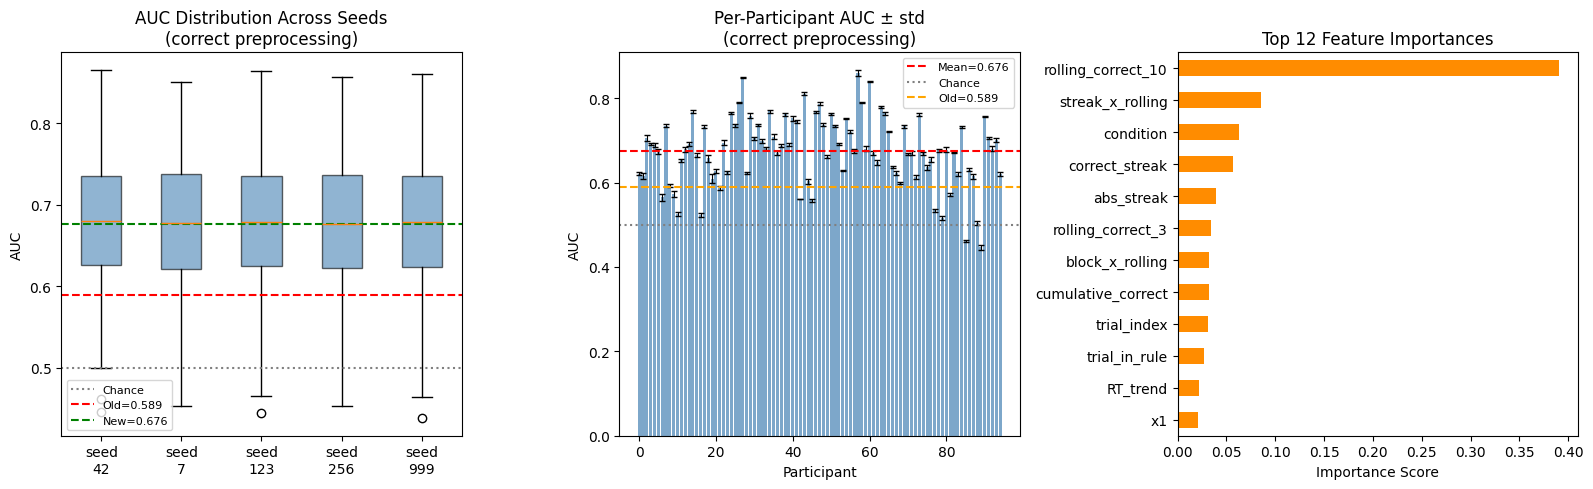


Done. All results saved to marcel_binz_data/


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
print(f"Loaded | Shape: {df.shape}")

# ── 2. FEATURES & TARGET ──────────────────────────────────────────────────────
DROP = ['correct', 'action', 'correct_category', 'reward',
        'participant', 'object', 'all_features', 'RT']
y = df['correct']
X = df.drop(columns=[c for c in DROP if c in df.columns])

# Encode any remaining categoricals
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
X[X.select_dtypes('bool').columns] = X.select_dtypes('bool').astype(int)
FEATURES = X.columns.tolist()
print(f"Features ({len(FEATURES)}): {FEATURES}")

# ── 3. LOPO CV ────────────────────────────────────────────────────────────────
participants = sorted(df['participant'].unique())
SEEDS        = [42, 7, 123, 256, 999]
CHECKPOINT   = '/content/drive/MyDrive/marcel_binz_data/lopo_results.csv'

try:
    done_df   = pd.read_csv(CHECKPOINT)
    done_keys = set(zip(done_df['seed'], done_df['participant']))
    all_rows  = done_df.to_dict('records')
    print(f"Resuming — {len(done_keys)} done.")
except FileNotFoundError:
    done_keys = set()
    all_rows  = []
    print("Starting fresh.")

for seed in SEEDS:
    print(f"\n{'─'*45}")
    print(f"  SEED {seed}")
    print(f"{'─'*45}")

    for test_p in participants:
        if (seed, test_p) in done_keys:
            continue

        train_mask = df['participant'] != test_p
        test_mask  = df['participant'] == test_p

        X_train, y_train = X[train_mask].values, y[train_mask].values
        X_test,  y_test  = X[test_mask].values,  y[test_mask].values

        if len(X_train) == 0 or len(X_test) == 0:
            continue

        spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

        scaler  = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)

        model = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=spw, eval_metric='auc',
            random_state=seed, verbosity=0
        )
        model.fit(X_train, y_train)

        prob = model.predict_proba(X_test)[:, 1]
        auc  = roc_auc_score(y_test, prob)
        p_correct = y_test.mean()

        all_rows.append({
            'seed':        seed,
            'participant': test_p,
            'auc':         auc,
            'p_correct':   p_correct
        })

        pd.DataFrame(all_rows).to_csv(CHECKPOINT, index=False)

    seed_rows = [r for r in all_rows if r['seed'] == seed]
    if seed_rows:
        aucs = [r['auc'] for r in seed_rows]
        print(f"  Seed {seed} | AUC: {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

# ── 4. SUMMARY ────────────────────────────────────────────────────────────────
results_df   = pd.DataFrame(all_rows)
seed_summary = results_df.groupby('seed')['auc'].agg(['mean','std']).round(4)
p_summary    = results_df.groupby('participant')['auc'].agg(['mean','std']).reset_index()
p_summary.columns = ['participant','mean_auc','std_auc']
p_summary.to_csv('/content/drive/MyDrive/marcel_binz_data/per_participant_auc.csv', index=False)

old_auc = 0.589  # previous best on incorrectly preprocessed data

print(f"\n{'═'*50}")
print(f"AUC per seed:")
print(seed_summary.to_string())
print(f"\nOverall mean AUC : {results_df['auc'].mean():.3f}")
print(f"Seed stability   : {seed_summary['mean'].std():.4f}")
print(f"Previous AUC     : {old_auc:.3f} (old incorrect preprocessing)")
print(f"Improvement      : {results_df['auc'].mean() - old_auc:+.3f}")
print(f"Chance AUC       : 0.500")
print(f"{'═'*50}")

# ── 5. FEATURE IMPORTANCE ─────────────────────────────────────────────────────
scaler_f = StandardScaler()
X_all    = scaler_f.fit_transform(X)
spw_all  = (y == 0).sum() / (y == 1).sum()
final_model = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw_all, eval_metric='auc',
    random_state=42, verbosity=0
)
final_model.fit(X_all, y)
feat_imp = pd.Series(
    final_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)

# ── 6. PLOTS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# AUC per seed boxplot
seed_aucs = [results_df[results_df['seed']==s]['auc'].values for s in SEEDS]
axes[0].boxplot(seed_aucs, tick_labels=[f'seed\n{s}' for s in SEEDS],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].axhline(0.5,     color='gray',  linestyle=':', label='Chance')
axes[0].axhline(old_auc, color='red',   linestyle='--', label=f'Old={old_auc}')
axes[0].axhline(results_df['auc'].mean(), color='green',
                linestyle='--', label=f"New={results_df['auc'].mean():.3f}")
axes[0].set_title('AUC Distribution Across Seeds\n(correct preprocessing)')
axes[0].set_ylabel('AUC')
axes[0].legend(fontsize=8)

# Per-participant AUC
axes[1].bar(p_summary['participant'], p_summary['mean_auc'],
            yerr=p_summary['std_auc'], color='steelblue', alpha=0.7,
            ecolor='black', capsize=2, error_kw={'linewidth':0.8})
axes[1].axhline(results_df['auc'].mean(), color='red', linestyle='--',
                label=f"Mean={results_df['auc'].mean():.3f}")
axes[1].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[1].axhline(old_auc, color='orange', linestyle='--', label=f'Old={old_auc}')
axes[1].set_title('Per-Participant AUC ± std\n(correct preprocessing)')
axes[1].set_xlabel('Participant')
axes[1].set_ylabel('AUC')
axes[1].legend(fontsize=8)

# Feature importance
feat_imp.head(12)[::-1].plot(kind='barh', ax=axes[2], color='darkorange')
axes[2].set_title('Top 12 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/lopo_results.png', dpi=150)
plt.show()

print("\nDone. All results saved to marcel_binz_data/")

**LSTM**

Loaded | Shape: (33060, 29)
LSTM features (18): ['prev_correct', 'prev_reward', 'rolling_correct_3', 'rolling_correct_5', 'rolling_correct_10', 'trial_in_rule', 'correct_streak', 'abs_streak', 'block_x_rolling', 'streak_x_rolling', 'prev_RT', 'rolling_RT_3', 'RT_trend', 'x1', 'x2', 'x3', 'condition', 'category']
Starting fresh.
  P 0 | LSTM=0.595 | p_correct=0.688 | saved ✓
  P 1 | LSTM=0.667 | p_correct=0.599 | saved ✓
  P 2 | LSTM=0.629 | p_correct=0.613 | saved ✓
  P 3 | LSTM=0.566 | p_correct=0.759 | saved ✓
  P 4 | LSTM=0.651 | p_correct=0.679 | saved ✓
  P 5 | LSTM=0.655 | p_correct=0.620 | saved ✓
  P 6 | LSTM=0.622 | p_correct=0.565 | saved ✓
  P 7 | LSTM=0.740 | p_correct=0.712 | saved ✓
  P 8 | LSTM=0.546 | p_correct=0.668 | saved ✓
  P 9 | LSTM=0.595 | p_correct=0.562 | saved ✓
  P10 | LSTM=0.531 | p_correct=0.574 | saved ✓
  P11 | LSTM=0.664 | p_correct=0.766 | saved ✓
  P12 | LSTM=0.655 | p_correct=0.620 | saved ✓
  P13 | LSTM=0.658 | p_correct=0.685 | saved ✓
  P14 | LSTM

  P28 | LSTM=0.563 | p_correct=0.678 | saved ✓
  P29 | LSTM=0.698 | p_correct=0.829 | saved ✓
  P30 | LSTM=0.690 | p_correct=0.747 | saved ✓
  P31 | LSTM=0.723 | p_correct=0.840 | saved ✓
  P32 | LSTM=0.590 | p_correct=0.839 | saved ✓
  P33 | LSTM=0.640 | p_correct=0.802 | saved ✓
  P34 | LSTM=0.693 | p_correct=0.850 | saved ✓
  P35 | LSTM=0.542 | p_correct=0.914 | saved ✓
  P36 | LSTM=0.647 | p_correct=0.779 | saved ✓
  P37 | LSTM=0.682 | p_correct=0.691 | saved ✓
  P38 | LSTM=0.771 | p_correct=0.815 | saved ✓
  P39 | LSTM=0.662 | p_correct=0.727 | saved ✓
  P40 | LSTM=0.750 | p_correct=0.777 | saved ✓
  P41 | LSTM=0.720 | p_correct=0.785 | saved ✓
  P42 | LSTM=0.527 | p_correct=0.571 | saved ✓
  P43 | LSTM=0.766 | p_correct=0.860 | saved ✓
  P44 | LSTM=0.618 | p_correct=0.525 | saved ✓
  P45 | LSTM=0.547 | p_correct=0.541 | saved ✓
  P46 | LSTM=0.770 | p_correct=0.747 | saved ✓
  P47 | LSTM=0.724 | p_correct=0.884 | saved ✓
  P48 | LSTM=0.681 | p_correct=0.743 | saved ✓
  P49 | LSTM=

  P50 | LSTM=0.772 | p_correct=0.776 | saved ✓
  P51 | LSTM=0.684 | p_correct=0.818 | saved ✓
  P52 | LSTM=0.664 | p_correct=0.880 | saved ✓
  P53 | LSTM=0.511 | p_correct=0.768 | saved ✓
  P54 | LSTM=0.751 | p_correct=0.804 | saved ✓
  P55 | LSTM=0.719 | p_correct=0.765 | saved ✓
  P56 | LSTM=0.538 | p_correct=0.912 | saved ✓
  P57 | LSTM=0.831 | p_correct=0.904 | saved ✓
  P58 | LSTM=0.787 | p_correct=0.805 | saved ✓
  P59 | LSTM=0.634 | p_correct=0.743 | saved ✓
  P60 | LSTM=0.827 | p_correct=0.908 | saved ✓
  P61 | LSTM=0.648 | p_correct=0.776 | saved ✓
  P62 | LSTM=0.603 | p_correct=0.599 | saved ✓
  P63 | LSTM=0.758 | p_correct=0.850 | saved ✓
  P64 | LSTM=0.755 | p_correct=0.821 | saved ✓
  P65 | LSTM=0.643 | p_correct=0.914 | saved ✓
  P66 | LSTM=0.575 | p_correct=0.699 | saved ✓
  P67 | LSTM=0.642 | p_correct=0.799 | saved ✓
  P68 | LSTM=0.528 | p_correct=0.706 | saved ✓
  P69 | LSTM=0.701 | p_correct=0.856 | saved ✓
  P70 | LSTM=0.660 | p_correct=0.718 | saved ✓
  P71 | LSTM=

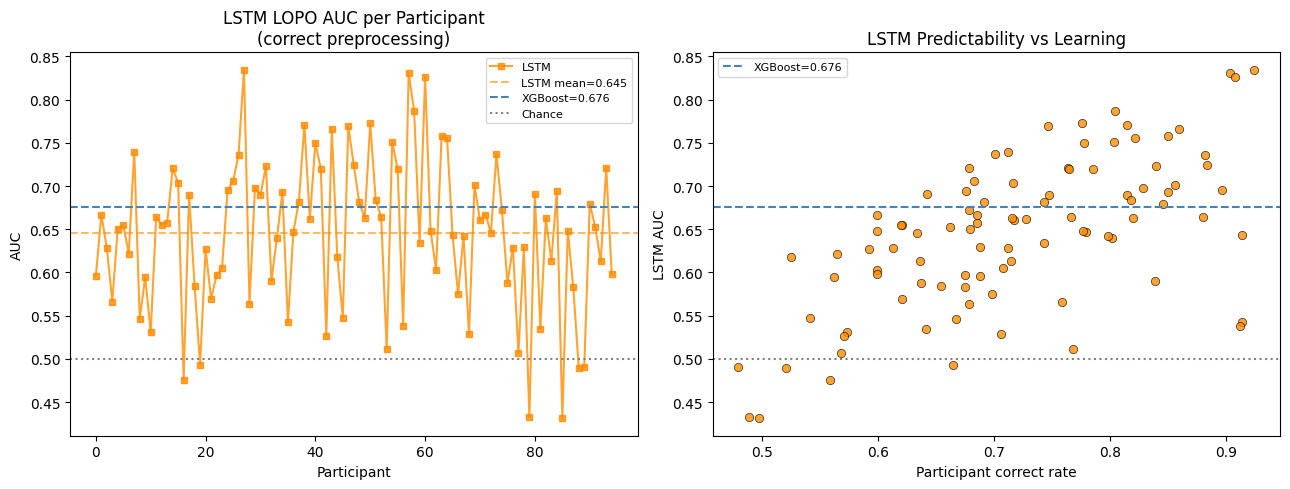


Done. Results saved.


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
print(f"Loaded | Shape: {df.shape}")

# ── 2. LSTM FEATURES ──────────────────────────────────────────────────────────
# Sequence features — what the LSTM sees at each timestep
LSTM_FEATS = [
    'prev_correct', 'prev_reward',
    'rolling_correct_3', 'rolling_correct_5', 'rolling_correct_10',
    'trial_in_rule', 'correct_streak', 'abs_streak',
    'block_x_rolling', 'streak_x_rolling',
    'prev_RT', 'rolling_RT_3', 'RT_trend',
    'x1', 'x2', 'x3', 'condition', 'category'
]
LSTM_FEATS = [f for f in LSTM_FEATS if f in df.columns]
SEQ_LEN    = 10
print(f"LSTM features ({len(LSTM_FEATS)}): {LSTM_FEATS}")

# ── 3. SEQUENCE BUILDER ───────────────────────────────────────────────────────
def make_sequences(X_arr, y_arr, seq_len):
    """Build overlapping sequences of length seq_len."""
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr)):
        Xs.append(X_arr[i-seq_len:i])
        ys.append(y_arr[i])
    return np.array(Xs), np.array(ys)

def build_sequences_for_participants(df_subset, participants, seq_len):
    """Build sequences grouped by participant+rule_id."""
    X_seqs, y_seqs = [], []
    for p in participants:
        for rule in sorted(df_subset[df_subset['participant']==p]['rule_id'].unique()):
            mask = (df_subset['participant']==p) & (df_subset['rule_id']==rule)
            p_r_df = df_subset[mask].sort_values('trial_index')
            if len(p_r_df) <= seq_len:
                continue
            X_arr = p_r_df[LSTM_FEATS].values
            y_arr = p_r_df['correct'].values
            Xs, ys = make_sequences(X_arr, y_arr, seq_len)
            X_seqs.append(Xs)
            y_seqs.append(ys)
    if len(X_seqs) == 0:
        return np.array([]), np.array([])
    return np.concatenate(X_seqs), np.concatenate(y_seqs)

# ── 4. LOPO CV ────────────────────────────────────────────────────────────────
participants = sorted(df['participant'].unique())
CHECKPOINT   = '/content/drive/MyDrive/marcel_binz_data/lstm_lopo_results.csv'

try:
    done_df = pd.read_csv(CHECKPOINT)
    done_ps = set(done_df['participant'].values)
    results = done_df.to_dict('records')
    print(f"Resuming — {len(done_ps)} done.")
except FileNotFoundError:
    done_ps = set()
    results = []
    print("Starting fresh.")

for test_p in participants:
    if test_p in done_ps:
        print(f"  P{test_p:>2} | skipped")
        continue

    train_ps = [p for p in participants if p != test_p]

    # ── Scale — fit on train only ──────────────────────────────────────────
    train_mask = df['participant'] != test_p
    test_mask  = df['participant'] == test_p

    scaler = StandardScaler()
    df_train = df[train_mask].copy()
    df_test  = df[test_mask].copy()

    df_train[LSTM_FEATS] = scaler.fit_transform(df_train[LSTM_FEATS])
    df_test[LSTM_FEATS]  = scaler.transform(df_test[LSTM_FEATS])

    # ── Build sequences ────────────────────────────────────────────────────
    X_train, y_train = build_sequences_for_participants(df_train, train_ps,   SEQ_LEN)
    X_test,  y_test  = build_sequences_for_participants(df_test,  [test_p],   SEQ_LEN)

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"  P{test_p:>2} | skipped — no sequences")
        continue

    if len(np.unique(y_test)) < 2:
        print(f"  P{test_p:>2} | skipped — only one class in test")
        continue

    # ── Class weights ──────────────────────────────────────────────────────
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    class_weight = {0: pos/(neg+pos), 1: neg/(neg+pos)}

    # ── Build LSTM ────────────────────────────────────────────────────────
    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(32, input_shape=(SEQ_LEN, len(LSTM_FEATS)),
             return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dropout(0.2),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')

    es = EarlyStopping(monitor='val_loss', patience=5,
                       restore_best_weights=True, verbose=0)

    model.fit(
        X_train, y_train,
        epochs=30, batch_size=128,
        validation_split=0.1,
        class_weight=class_weight,
        callbacks=[es], verbose=0
    )

    y_prob = model.predict(X_test, verbose=0).flatten()
    auc    = roc_auc_score(y_test, y_prob)

    results.append({
        'participant': test_p,
        'lstm_auc':    auc,
        'p_correct':   y_test.mean()
    })

    pd.DataFrame(results).to_csv(CHECKPOINT, index=False)
    print(f"  P{test_p:>2} | LSTM={auc:.3f} | p_correct={y_test.mean():.3f} | saved ✓")

    tf.keras.backend.clear_session()

# ── 5. SUMMARY ────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
xgb_auc    = 0.676

print(f"\n{'═'*50}")
print(f"  LSTM    AUC : {results_df['lstm_auc'].mean():.3f} ± {results_df['lstm_auc'].std():.3f}")
print(f"  XGBoost AUC : {xgb_auc:.3f} (LOPO, 5 seeds)")
print(f"  Chance  AUC : 0.500")
print(f"  LSTM wins   : {(results_df['lstm_auc'] > xgb_auc).sum()} / {len(results_df)} participants")
print(f"{'═'*50}")

results_df.to_csv(CHECKPOINT, index=False)

# ── 6. PLOT ───────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(results_df))
axes[0].plot(x, results_df['lstm_auc'].values, 's-',
             color='darkorange', alpha=0.8, markersize=4, label='LSTM')
axes[0].axhline(results_df['lstm_auc'].mean(), color='darkorange',
                linestyle='--', alpha=0.6,
                label=f"LSTM mean={results_df['lstm_auc'].mean():.3f}")
axes[0].axhline(xgb_auc, color='steelblue', linestyle='--',
                label=f'XGBoost={xgb_auc:.3f}')
axes[0].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[0].set_title('LSTM LOPO AUC per Participant\n(correct preprocessing)')
axes[0].set_xlabel('Participant')
axes[0].set_ylabel('AUC')
axes[0].legend(fontsize=8)

axes[1].scatter(results_df['p_correct'], results_df['lstm_auc'],
                alpha=0.8, edgecolors='k', linewidths=0.5, color='darkorange')
axes[1].axhline(0.5,     color='gray',     linestyle=':')
axes[1].axhline(xgb_auc, color='steelblue', linestyle='--',
                label=f'XGBoost={xgb_auc}')
axes[1].set_xlabel('Participant correct rate')
axes[1].set_ylabel('LSTM AUC')
axes[1].set_title('LSTM Predictability vs Learning')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/lstm_results.png', dpi=150)
plt.show()
print("\nDone. Results saved.")

**Q-Learning**

Loaded | Shape: (33060, 29)

Unique actions per participant:
participant
0    [1, 0]
1    [0, 1]
2    [1, 0]
3    [0, 1]
4    [1, 0]
5    [0, 1]
6    [1, 0]
7    [0, 1]
8    [0, 1]
9    [1, 0]
Name: action, dtype: object

Unique actions globally:
[1 0]

Starting fresh.
  P 0 | Q=0.549 | alpha=0.258 | beta=0.36 | p_correct=0.671 | saved ✓
  P 1 | Q=0.484 | alpha=0.000 | beta=5.14 | p_correct=0.581 | saved ✓
  P 2 | Q=0.564 | alpha=1.000 | beta=0.52 | p_correct=0.611 | saved ✓
  P 3 | Q=0.534 | alpha=0.750 | beta=1.06 | p_correct=0.734 | saved ✓
  P 4 | Q=0.529 | alpha=0.000 | beta=7.82 | p_correct=0.663 | saved ✓
  P 5 | Q=0.568 | alpha=1.000 | beta=0.54 | p_correct=0.604 | saved ✓
  P 6 | Q=0.423 | alpha=0.250 | beta=0.96 | p_correct=0.560 | saved ✓
  P 7 | Q=0.473 | alpha=0.090 | beta=2.29 | p_correct=0.684 | saved ✓
  P 8 | Q=0.503 | alpha=0.000 | beta=5.51 | p_correct=0.663 | saved ✓
  P 9 | Q=0.617 | alpha=0.995 | beta=0.65 | p_correct=0.563 | saved ✓
  P10 | Q=0.540 | alpha=0.481 

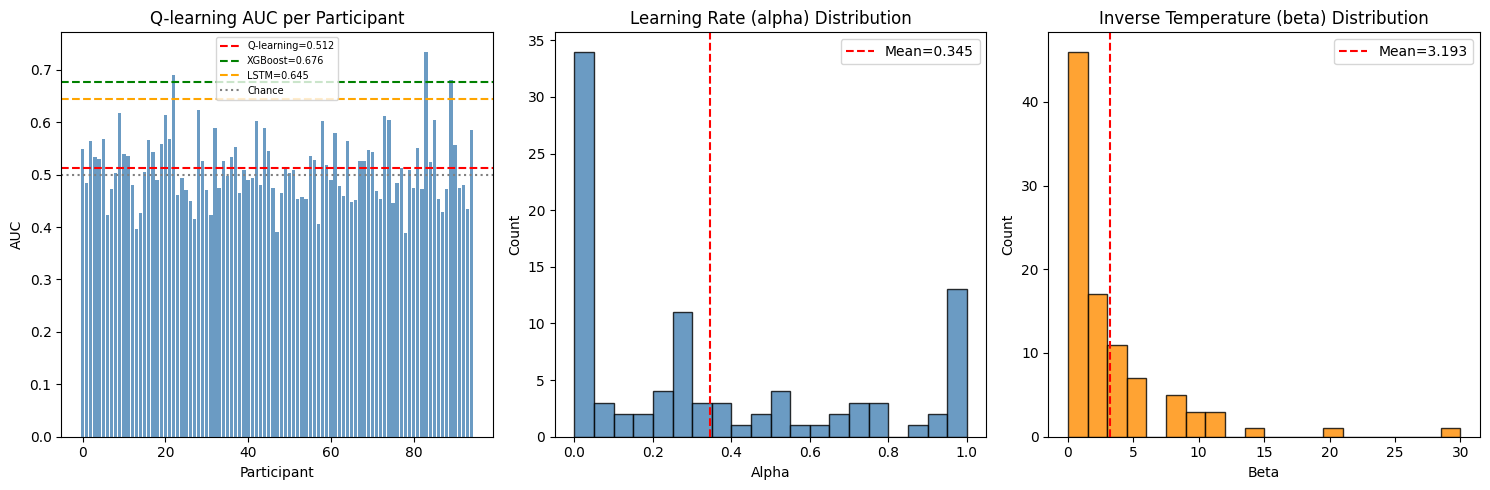


Done. Results saved.


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
print(f"Loaded | Shape: {df.shape}")

# ── 2. VERIFY 2-ACTION STRUCTURE ──────────────────────────────────────────────
print("\nUnique actions per participant:")
actions_per_p = df.groupby('participant')['action'].unique()
print(actions_per_p.head(10))

print("\nUnique actions globally:")
print(df['action'].unique())

# ── 3. 2-ACTION Q-LEARNING ────────────────────────────────────────────────────
# In this dataset action is binary (0 or 1) — perfect for 2-action Q-learning
# Each participant-rule combination is an independent learning episode

def q2_nll(params, actions, rewards):
    """2-action Q-learning negative log likelihood."""
    alpha, beta = params
    if not (0 < alpha < 1 and 0.01 < beta < 30):
        return 1e10

    Q = {0: 0.5, 1: 0.5}
    nll = 0.0

    for t in range(len(actions)):
        a = int(actions[t])
        r = float(rewards[t])

        # Softmax over 2 actions
        dQ  = np.clip(beta * (Q[1] - Q[0]), -500, 500)
        p1  = 1 / (1 + np.exp(-dQ))
        p_a = p1 if a == 1 else (1 - p1)
        nll -= np.log(p_a + 1e-10)

        # Update chosen action
        Q[a] += alpha * (r - Q[a])

    return nll

def fit_q2(actions, rewards):
    """Fit Q-learning with multiple random starts."""
    best_nll, best_params = np.inf, None
    for _ in range(20):
        a0 = np.random.uniform(0.01, 0.99)
        b0 = np.random.uniform(0.1,  15.0)
        try:
            res = minimize(
                q2_nll, x0=[a0, b0], args=(actions, rewards),
                method='Nelder-Mead',
                options={'maxiter': 3000, 'xatol': 1e-5, 'fatol': 1e-5}
            )
            if res.fun < best_nll:
                best_nll    = res.fun
                best_params = res.x
        except Exception:
            continue
    return best_params, best_nll

def q2_predict(params, actions, rewards, correct_category):
    """
    Trial-by-trial P(correct) using fitted Q-learning.
    Prediction for trial t uses history up to t-1.
    """
    alpha, beta = params
    Q     = {0: 0.5, 1: 0.5}
    probs = np.zeros(len(actions))

    for t in range(len(actions)):
        a  = int(actions[t])
        r  = float(rewards[t])
        cc = int(correct_category[t])

        # P(correct) = P(choosing correct_category)
        dQ  = np.clip(beta * (Q[1] - Q[0]), -500, 500)
        p1  = 1 / (1 + np.exp(-dQ))
        probs[t] = p1 if cc == 1 else (1 - p1)

        # Update Q
        Q[a] += alpha * (r - Q[a])

    return probs

# ── 4. LOPO — fit per participant, evaluate per rule ──────────────────────────
# Strategy: fit Q-learning on first 3 rules, predict on 4th rule
# This respects temporal order and avoids leakage

CHECKPOINT = '/content/drive/MyDrive/marcel_binz_data/qlearn_results.csv'

try:
    done_df = pd.read_csv(CHECKPOINT)
    done_ps = set(done_df['participant'].values)
    results = done_df.to_dict('records')
    print(f"\nResuming — {len(done_ps)} done.")
except FileNotFoundError:
    done_ps = set()
    results = []
    print("\nStarting fresh.")

participants = sorted(df['participant'].unique())

for test_p in participants:
    if test_p in done_ps:
        print(f"  P{test_p:>2} | skipped")
        continue

    p_df   = df[df['participant'] == test_p].copy()
    rules  = sorted(p_df['rule_id'].unique())
    p_aucs = []
    p_alphas, p_betas = [], []

    for test_rule in rules:
        # Train on all other rules for this participant
        train_df = p_df[p_df['rule_id'] != test_rule].sort_values(
                   ['rule_id','trial_index'])
        test_df  = p_df[p_df['rule_id'] == test_rule].sort_values('trial_index')

        if len(train_df) == 0 or len(test_df) == 0:
            continue

        actions_train  = train_df['action'].values
        rewards_train  = train_df['reward'].values
        actions_test   = test_df['action'].values
        rewards_test   = test_df['reward'].values
        correct_test   = test_df['correct_category'].values
        y_test         = test_df['correct'].values

        if len(np.unique(y_test)) < 2:
            continue

        # Fit on training rules
        try:
            params, nll = fit_q2(actions_train, rewards_train)
            if params is None:
                continue
            alpha, beta = params

            # Predict on test rule
            probs = q2_predict(params, actions_test, rewards_test, correct_test)
            auc   = roc_auc_score(y_test, probs)

            p_aucs.append(auc)
            p_alphas.append(alpha)
            p_betas.append(beta)
        except Exception as e:
            continue

    if len(p_aucs) == 0:
        continue

    mean_auc   = np.mean(p_aucs)
    mean_alpha = np.mean(p_alphas)
    mean_beta  = np.mean(p_betas)
    p_correct  = p_df['correct'].mean()

    results.append({
        'participant': test_p,
        'q_auc':       mean_auc,
        'alpha':       mean_alpha,
        'beta':        mean_beta,
        'p_correct':   p_correct
    })

    pd.DataFrame(results).to_csv(CHECKPOINT, index=False)
    print(f"  P{test_p:>2} | Q={mean_auc:.3f} | "
          f"alpha={mean_alpha:.3f} | beta={mean_beta:.2f} | "
          f"p_correct={p_correct:.3f} | saved ✓")

# ── 5. SUMMARY ────────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results).dropna()

xgb_auc  = 0.676
lstm_auc = 0.645

print(f"\n{'═'*55}")
print(f"  Q-learning AUC : {results_df['q_auc'].mean():.3f} ± {results_df['q_auc'].std():.3f}")
print(f"  XGBoost    AUC : {xgb_auc:.3f}")
print(f"  LSTM       AUC : {lstm_auc:.3f}")
print(f"  Chance     AUC : 0.500")
print(f"\n  Mean alpha (learning rate)  : {results_df['alpha'].mean():.3f} ± {results_df['alpha'].std():.3f}")
print(f"  Mean beta  (inverse temp)   : {results_df['beta'].mean():.3f} ± {results_df['beta'].std():.3f}")
print(f"{'═'*55}")

# ── 6. PLOTS ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# AUC per participant
axes[0].bar(results_df['participant'], results_df['q_auc'],
            color='steelblue', alpha=0.8)
axes[0].axhline(results_df['q_auc'].mean(), color='red', linestyle='--',
                label=f"Q-learning={results_df['q_auc'].mean():.3f}")
axes[0].axhline(xgb_auc,  color='green',  linestyle='--', label=f'XGBoost={xgb_auc}')
axes[0].axhline(lstm_auc, color='orange', linestyle='--', label=f'LSTM={lstm_auc}')
axes[0].axhline(0.5,      color='gray',   linestyle=':',  label='Chance')
axes[0].set_title('Q-learning AUC per Participant')
axes[0].set_xlabel('Participant')
axes[0].set_ylabel('AUC')
axes[0].legend(fontsize=7)

# Alpha distribution
axes[1].hist(results_df['alpha'], bins=20,
             color='steelblue', edgecolor='black', alpha=0.8)
axes[1].axvline(results_df['alpha'].mean(), color='red', linestyle='--',
                label=f"Mean={results_df['alpha'].mean():.3f}")
axes[1].set_title('Learning Rate (alpha) Distribution')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('Count')
axes[1].legend()

# Beta distribution
axes[2].hist(results_df['beta'], bins=20,
             color='darkorange', edgecolor='black', alpha=0.8)
axes[2].axvline(results_df['beta'].mean(), color='red', linestyle='--',
                label=f"Mean={results_df['beta'].mean():.3f}")
axes[2].set_title('Inverse Temperature (beta) Distribution')
axes[2].set_xlabel('Beta')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/qlearn_results.png', dpi=150)
plt.show()
print("\nDone. Results saved.")

**Win-Stay Lose-Shift**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded | Shape: (33060, 29) | Participants: 95

Profiles shape: (95, 17)
       participant  overall_acc  early_acc  mid_acc  late_acc  learning_slope  \
count       95.000       95.000     95.000   95.000    95.000          95.000   
mean        47.000        0.700      0.626    0.746     0.775           0.149   
std         27.568        0.103      0.087    0.114     0.129           0.094   
min          0.000        0.476      0.395    0.484     0.461          -0.062   
25%         23.500        0.629      0.561    0.688     0.680           0.078   
50%         47.000        0.690      0.627    0.740     0.789           0.163   
75%         70.500        0.783      0.689    0.822     0.879           0.208   
max         94.000        0.889      0.815    0.969     1.000           0.352   

       acc_std  streak_mean  streak_max  recovery_speed  win_stay_ra

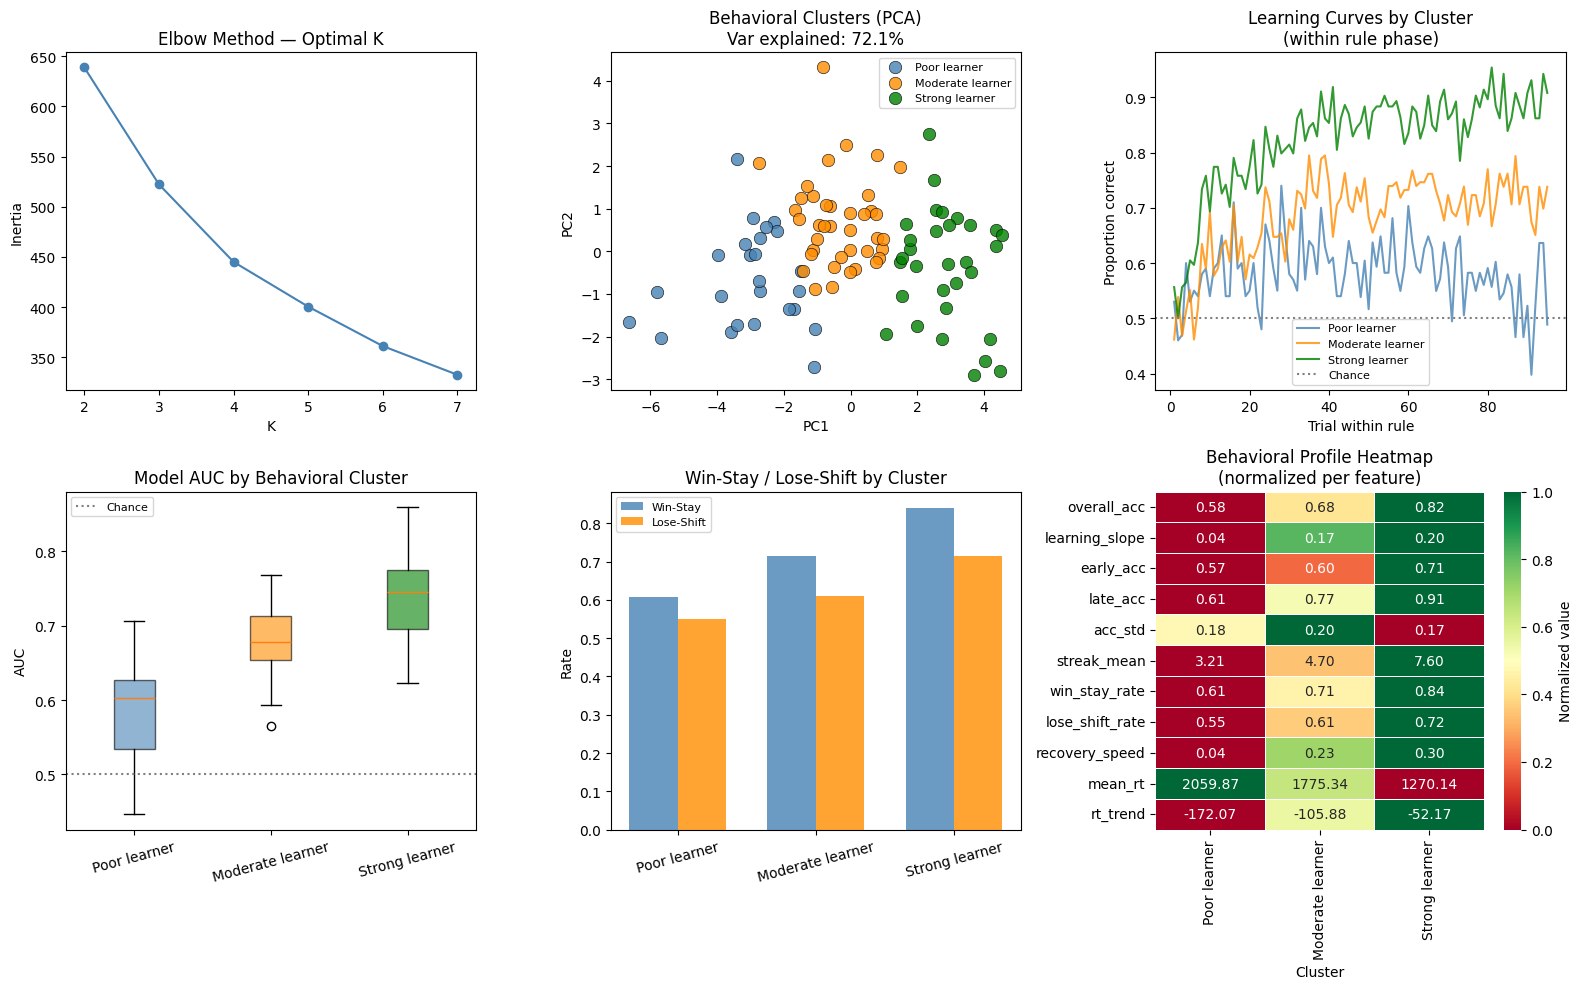


Done. Behavioral analysis saved.

Final cluster summary:
                  overall_acc  learning_slope  win_stay_rate  lose_shift_rate  model_auc  recovery_speed   mean_rt
cluster_label                                                                                                     
Moderate learner        0.682           0.174          0.715            0.610      0.681           0.229  1775.337
Poor learner            0.584           0.042          0.607            0.549      0.588           0.045  2059.867
Strong learner          0.818           0.203          0.841            0.716      0.740           0.305  1270.144


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD CORRECT DATA ──────────────────────────────────────────────────────
df          = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
ms_df       = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/per_participant_auc.csv')
print(f"Loaded | Shape: {df.shape} | Participants: {df['participant'].nunique()}")

# ── 2. BUILD PARTICIPANT-LEVEL BEHAVIORAL PROFILE ─────────────────────────────
# One row per participant — summarize behavioral patterns across all rules
participant_profiles = []

for p in sorted(df['participant'].unique()):
    p_df = df[df['participant'] == p].copy()

    # ── Learning metrics ──────────────────────────────────────────────────────
    overall_acc  = p_df['correct'].mean()

    # Early/mid/late within each rule, then average across rules
    early_acc, mid_acc, late_acc = [], [], []
    for rule in p_df['rule_id'].unique():
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        n    = len(r_df)
        early_acc.append(r_df.iloc[:n//3]['correct'].mean())
        mid_acc.append(  r_df.iloc[n//3:2*n//3]['correct'].mean())
        late_acc.append( r_df.iloc[2*n//3:]['correct'].mean())

    early_acc = np.mean(early_acc)
    mid_acc   = np.mean(mid_acc)
    late_acc  = np.mean(late_acc)
    learning_slope = late_acc - early_acc

    # ── Consistency ───────────────────────────────────────────────────────────
    acc_std    = p_df['correct'].rolling(10).mean().std()
    streak_mean= p_df['correct_streak'].abs().mean()
    streak_max = p_df['correct_streak'].abs().max()

    # ── Rule-change response — how fast do they recover after rule switch? ────
    # Compare accuracy in first 10 trials of each rule vs last 10
    recovery_speeds = []
    for rule in sorted(p_df['rule_id'].unique()):
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        if len(r_df) >= 20:
            first_10 = r_df.iloc[:10]['correct'].mean()
            last_10  = r_df.iloc[-10:]['correct'].mean()
            recovery_speeds.append(last_10 - first_10)
    recovery_speed = np.mean(recovery_speeds) if recovery_speeds else np.nan

    # ── Win-Stay Lose-Shift ───────────────────────────────────────────────────
    stayed_after_win  = ((p_df['prev_correct']==1) & (p_df['correct']==1)).sum()
    total_after_win   = (p_df['prev_correct']==1).sum()
    win_stay_rate     = stayed_after_win / max(total_after_win, 1)

    shifted_after_loss= ((p_df['prev_correct']==0) & (p_df['correct']==1)).sum()
    total_after_loss  = (p_df['prev_correct']==0).sum()
    lose_shift_rate   = shifted_after_loss / max(total_after_loss, 1)

    # ── RT metrics ────────────────────────────────────────────────────────────
    mean_rt    = p_df['RT'].mean()
    rt_trend   = p_df['RT_trend'].mean()   # negative = speeding up = more confident
    rt_std     = p_df['RT'].std()

    # ── Model predictability ──────────────────────────────────────────────────
    try:
        p_auc     = ms_df[ms_df['participant']==p]['mean_auc'].values[0]
        p_auc_std = ms_df[ms_df['participant']==p]['std_auc'].values[0]
    except Exception:
        p_auc, p_auc_std = np.nan, np.nan

    participant_profiles.append({
        'participant':    p,
        'overall_acc':    overall_acc,
        'early_acc':      early_acc,
        'mid_acc':        mid_acc,
        'late_acc':       late_acc,
        'learning_slope': learning_slope,
        'acc_std':        acc_std,
        'streak_mean':    streak_mean,
        'streak_max':     streak_max,
        'recovery_speed': recovery_speed,
        'win_stay_rate':  win_stay_rate,
        'lose_shift_rate':lose_shift_rate,
        'mean_rt':        mean_rt,
        'rt_trend':       rt_trend,
        'rt_std':         rt_std,
        'model_auc':      p_auc,
        'model_auc_std':  p_auc_std
    })

profiles_df = pd.DataFrame(participant_profiles)
profiles_df.to_csv('/content/drive/MyDrive/marcel_binz_data/participant_profiles.csv', index=False)
print(f"\nProfiles shape: {profiles_df.shape}")
print(profiles_df.describe().round(3))

# ── 3. CLUSTER INTO BEHAVIORAL TYPES ─────────────────────────────────────────
cluster_features = [
    'overall_acc', 'learning_slope', 'early_acc', 'late_acc',
    'acc_std', 'streak_mean', 'win_stay_rate', 'lose_shift_rate',
    'recovery_speed', 'mean_rt', 'rt_trend'
]

cluster_df = profiles_df[cluster_features].dropna()
scaler_c   = StandardScaler()
X_cluster  = scaler_c.fit_transform(cluster_df)

# Elbow method
inertias = []
K_range  = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# Fit k=3
km = KMeans(n_clusters=3, random_state=42, n_init=20)
profiles_df.loc[cluster_df.index, 'cluster'] = km.fit_predict(X_cluster)
profiles_df['cluster'] = profiles_df['cluster'].astype(int)

# Label by overall accuracy
cluster_acc = profiles_df.groupby('cluster')['overall_acc'].mean().sort_values()
label_map   = {old: new for new, old in enumerate(cluster_acc.index)}
profiles_df['cluster']       = profiles_df['cluster'].map(label_map)
profiles_df['cluster_label'] = profiles_df['cluster'].map({
    0: 'Poor learner',
    1: 'Moderate learner',
    2: 'Strong learner'
})

print(f"\nCluster sizes:")
print(profiles_df['cluster_label'].value_counts())

# ── 4. CLUSTER SUMMARY ────────────────────────────────────────────────────────
summary_cols = cluster_features + ['model_auc']
cluster_summary = profiles_df.groupby('cluster_label')[summary_cols].mean().round(3)
print(f"\nCluster summary:")
print(cluster_summary.T.to_string())

# ── 5. ANOVA TESTS ────────────────────────────────────────────────────────────
print(f"\nANOVA tests across clusters:")
for feat in ['overall_acc', 'learning_slope', 'win_stay_rate',
             'lose_shift_rate', 'model_auc', 'recovery_speed',
             'mean_rt', 'rt_trend']:
    groups = [profiles_df[profiles_df['cluster']==c][feat].dropna().values
              for c in sorted(profiles_df['cluster'].unique())]
    f, p = f_oneway(*groups)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {feat:<22} F={f:>7.2f}  p={p:.4f}  {sig}")

# ── 6. PCA ────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
profiles_df.loc[cluster_df.index, 'pca1'] = X_pca[:, 0]
profiles_df.loc[cluster_df.index, 'pca2'] = X_pca[:, 1]
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.round(3)}")

# ── 7. PLOTS ──────────────────────────────────────────────────────────────────
colors        = {0: 'steelblue', 1: 'darkorange', 2: 'green'}
cluster_order = ['Poor learner', 'Moderate learner', 'Strong learner']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Elbow
axes[0,0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0,0].set_title('Elbow Method — Optimal K')
axes[0,0].set_xlabel('K')
axes[0,0].set_ylabel('Inertia')

# PCA scatter
for c in sorted(profiles_df['cluster'].dropna().unique()):
    mask = profiles_df['cluster'] == c
    axes[0,1].scatter(
        profiles_df.loc[mask,'pca1'],
        profiles_df.loc[mask,'pca2'],
        c=colors[int(c)], label=cluster_order[int(c)],
        alpha=0.8, edgecolors='k', linewidths=0.5, s=80
    )
axes[0,1].set_title(f'Behavioral Clusters (PCA)\n'
                    f'Var explained: {pca.explained_variance_ratio_.sum():.1%}')
axes[0,1].set_xlabel('PC1')
axes[0,1].set_ylabel('PC2')
axes[0,1].legend(fontsize=8)

# Learning curves per cluster
for c in sorted(profiles_df['cluster'].dropna().unique()):
    p_ids = profiles_df[profiles_df['cluster']==c]['participant'].values
    c_df  = df[df['participant'].isin(p_ids)]
    curve = c_df.groupby('trial_in_rule')['correct'].mean()
    axes[0,2].plot(curve.index, curve.values,
                   color=colors[int(c)], label=cluster_order[int(c)], alpha=0.8)
axes[0,2].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[0,2].set_title('Learning Curves by Cluster\n(within rule phase)')
axes[0,2].set_xlabel('Trial within rule')
axes[0,2].set_ylabel('Proportion correct')
axes[0,2].legend(fontsize=8)

# Model AUC by cluster
auc_by_cluster = [profiles_df[profiles_df['cluster_label']==c]['model_auc'].dropna().values
                  for c in cluster_order]
bp = axes[1,0].boxplot(auc_by_cluster, tick_labels=cluster_order,
                        patch_artist=True)
for patch, c in zip(bp['boxes'], [0,1,2]):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
axes[1,0].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[1,0].set_title('Model AUC by Behavioral Cluster')
axes[1,0].set_ylabel('AUC')
axes[1,0].legend(fontsize=8)
axes[1,0].tick_params(axis='x', rotation=15)

# Win-stay / Lose-shift
x     = np.arange(3)
width = 0.35
ws    = [profiles_df[profiles_df['cluster_label']==c]['win_stay_rate'].mean()
         for c in cluster_order]
ls    = [profiles_df[profiles_df['cluster_label']==c]['lose_shift_rate'].mean()
         for c in cluster_order]
axes[1,1].bar(x-width/2, ws, width, label='Win-Stay',   color='steelblue',  alpha=0.8)
axes[1,1].bar(x+width/2, ls, width, label='Lose-Shift', color='darkorange', alpha=0.8)
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(cluster_order, rotation=15)
axes[1,1].set_title('Win-Stay / Lose-Shift by Cluster')
axes[1,1].set_ylabel('Rate')
axes[1,1].legend(fontsize=8)

# Heatmap
heatmap_data = profiles_df.groupby('cluster_label')[cluster_features].mean()
heatmap_data = heatmap_data.loc[cluster_order]
heatmap_norm = (heatmap_data - heatmap_data.min()) / \
               (heatmap_data.max() - heatmap_data.min())
sns.heatmap(heatmap_norm.T, annot=heatmap_data.T.round(2), fmt='.2f',
            cmap='RdYlGn', ax=axes[1,2], linewidths=0.5,
            cbar_kws={'label':'Normalized value'})
axes[1,2].set_title('Behavioral Profile Heatmap\n(normalized per feature)')
axes[1,2].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/behavioral_analysis.png', dpi=150)
plt.show()

profiles_df.to_csv('/content/drive/MyDrive/marcel_binz_data/participant_profiles.csv', index=False)
print("\nDone. Behavioral analysis saved.")
print(f"\nFinal cluster summary:")
print(profiles_df.groupby('cluster_label')[
    ['overall_acc','learning_slope','win_stay_rate',
     'lose_shift_rate','model_auc','recovery_speed','mean_rt']
].mean().round(3).to_string())

Loaded | lstm: (95, 3) | profiles: (95, 21)

Merged: (95, 15)

═══════════════════════════════════════════════════════
XGBoost mean AUC : 0.676 ± 0.083
LSTM    mean AUC : 0.645 ± 0.087
Mean gap (XGB-LSTM) : 0.030
XGB wins  : 76 / 95
LSTM wins : 19 / 95
═══════════════════════════════════════════════════════

Gap by behavioral cluster:
                  xgb_auc  lstm_auc    gap
cluster_label                             
Moderate learner    0.681     0.655  0.026
Poor learner        0.588     0.569  0.020
Strong learner      0.740     0.695  0.045

Correlation with XGB−LSTM gap:
  overall_acc            r = +0.324
  learning_slope         r = -0.024
  streak_mean            r = +0.136
  acc_std                r = -0.464
  win_stay_rate          r = +0.291
  lose_shift_rate        r = +0.360
  recovery_speed         r = +0.140
  mean_rt                r = -0.021
  rt_trend               r = +0.147

Top 10 participants where LSTM > XGBoost:
    participant   xgb_auc  lstm_auc       gap    

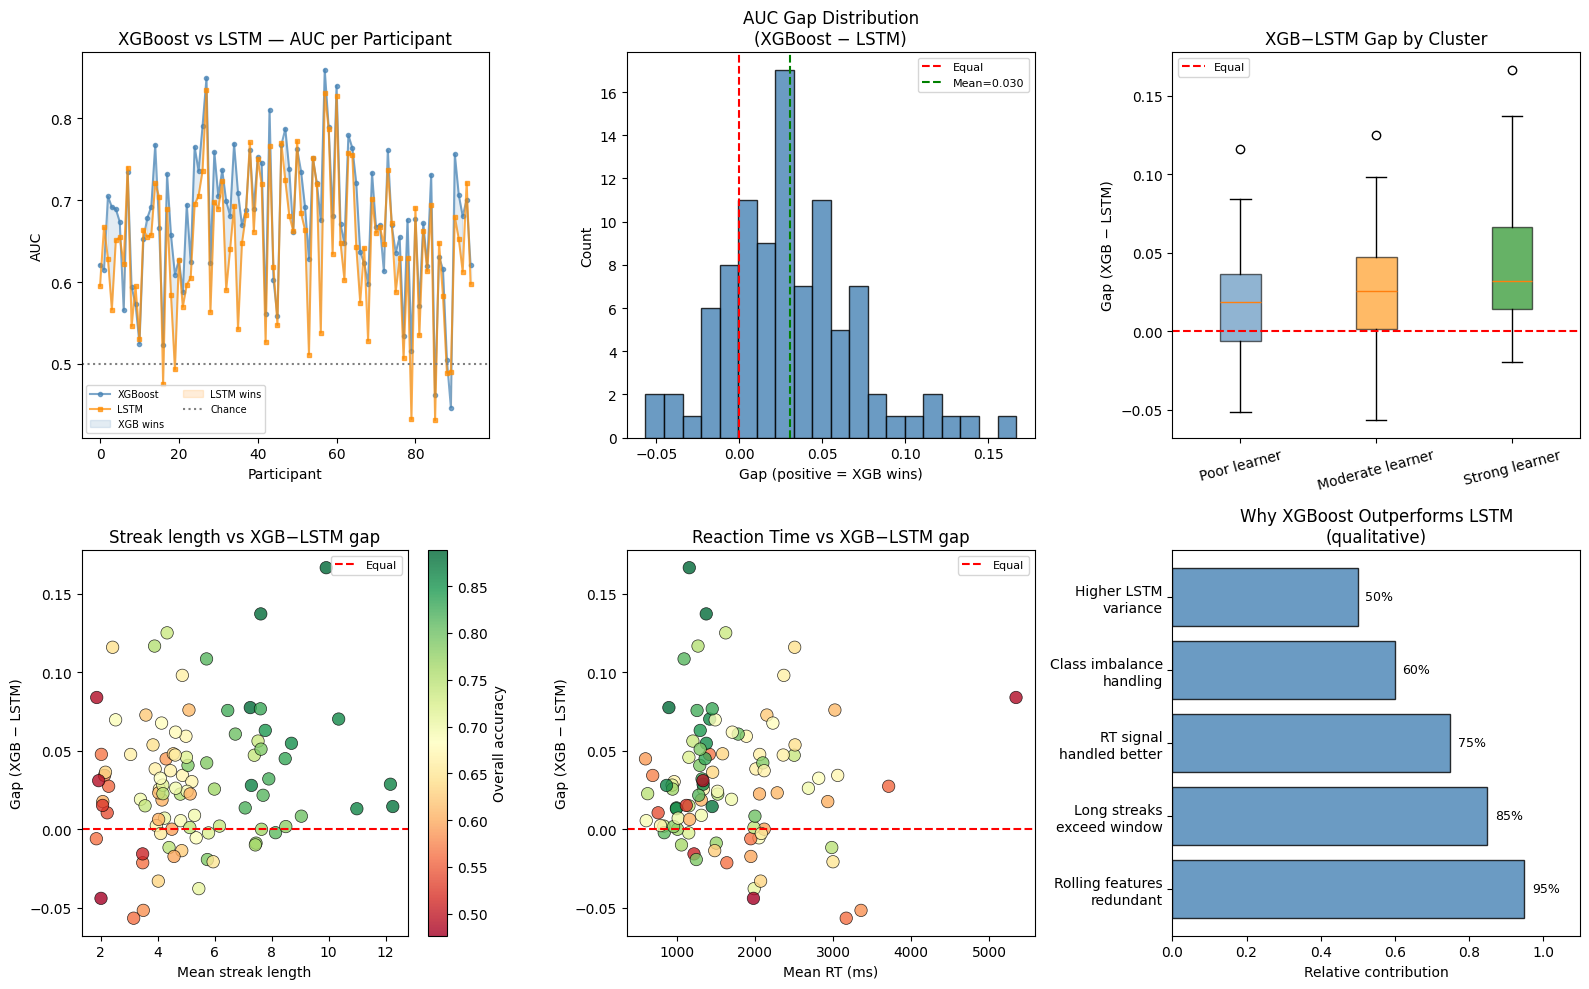


Done. LSTM failure analysis saved.


In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD ───────────────────────────────────────────────────────────────────
df          = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
profiles_df = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/participant_profiles.csv')
lstm_df     = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/lstm_lopo_results.csv')
ms_df       = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/per_participant_auc.csv')
print(f"Loaded | lstm: {lstm_df.shape} | profiles: {profiles_df.shape}")

# ── 2. MERGE ──────────────────────────────────────────────────────────────────
analysis = lstm_df.merge(
    profiles_df[['participant','cluster_label','overall_acc',
                 'learning_slope','acc_std','streak_mean',
                 'win_stay_rate','lose_shift_rate',
                 'recovery_speed','mean_rt','rt_trend']],
    on='participant', how='left'
)
analysis = analysis.merge(
    ms_df.rename(columns={'mean_auc':'xgb_auc'})[['participant','xgb_auc']],
    on='participant', how='left'
)
analysis['gap'] = analysis['xgb_auc'] - analysis['lstm_auc']
print(f"\nMerged: {analysis.shape}")

# ── 3. OVERALL COMPARISON ─────────────────────────────────────────────────────
print(f"\n{'═'*55}")
print(f"XGBoost mean AUC : {analysis['xgb_auc'].mean():.3f} ± {analysis['xgb_auc'].std():.3f}")
print(f"LSTM    mean AUC : {analysis['lstm_auc'].mean():.3f} ± {analysis['lstm_auc'].std():.3f}")
print(f"Mean gap (XGB-LSTM) : {analysis['gap'].mean():.3f}")
print(f"XGB wins  : {(analysis['gap']>0).sum()} / {len(analysis)}")
print(f"LSTM wins : {(analysis['gap']<0).sum()} / {len(analysis)}")
print(f"{'═'*55}")

# ── 4. GAP BY CLUSTER ─────────────────────────────────────────────────────────
print(f"\nGap by behavioral cluster:")
print(analysis.groupby('cluster_label')[['xgb_auc','lstm_auc','gap']].mean().round(3).to_string())

# ── 5. CORRELATION — what predicts the gap? ───────────────────────────────────
print(f"\nCorrelation with XGB−LSTM gap:")
for feat in ['overall_acc','learning_slope','streak_mean',
             'acc_std','win_stay_rate','lose_shift_rate',
             'recovery_speed','mean_rt','rt_trend']:
    corr = analysis['gap'].corr(analysis[feat])
    print(f"  {feat:<22} r = {corr:+.3f}")

# ── 6. WHEN DOES LSTM WIN? ────────────────────────────────────────────────────
print(f"\nTop 10 participants where LSTM > XGBoost:")
lstm_wins = analysis[analysis['gap']<0].sort_values('gap')
print(lstm_wins[['participant','xgb_auc','lstm_auc','gap',
                 'cluster_label','overall_acc','streak_mean',
                 'mean_rt']].head(10).to_string())

# ── 7. 5 REASONS — with evidence from correct data ────────────────────────────
print(f"\n{'═'*55}")
print("REASON 1: Rolling features already encode the sequence")
print(f"  rolling_correct_10 = mean of last 10 trials (= LSTM window)")
print(f"  XGBoost gets this explicitly — LSTM must learn it from scratch")

print(f"\nREASON 2: Strong learners have long streaks LSTM can't track")
strong = analysis[analysis['cluster_label']=='Strong learner']
poor   = analysis[analysis['cluster_label']=='Poor learner']
print(f"  Strong learner mean streak : {profiles_df[profiles_df['cluster_label']=='Strong learner']['streak_mean'].mean():.2f}")
print(f"  Poor   learner mean streak : {profiles_df[profiles_df['cluster_label']=='Poor learner']['streak_mean'].mean():.2f}")
print(f"  LSTM window=10 misses streaks longer than 10 trials")

print(f"\nREASON 3: RT signal benefits XGBoost more than LSTM")
print(f"  XGBoost: prev_RT, rolling_RT_3, RT_trend as direct features")
print(f"  LSTM: must learn RT-correctness relationship from raw sequence")
print(f"  Mean RT difference strong vs poor: "
      f"{profiles_df[profiles_df['cluster_label']=='Strong learner']['mean_rt'].mean():.0f} vs "
      f"{profiles_df[profiles_df['cluster_label']=='Poor learner']['mean_rt'].mean():.0f} ms")

print(f"\nREASON 4: Class imbalance handling")
print(f"  Target: {df['correct'].mean():.1%} correct vs {1-df['correct'].mean():.1%} incorrect")
print(f"  XGBoost: scale_pos_weight per fold — precise")
print(f"  LSTM: batch-level class_weight — less granular")

print(f"\nREASON 5: LSTM variance is higher — less stable")
print(f"  XGBoost AUC std : {analysis['xgb_auc'].std():.3f}")
print(f"  LSTM    AUC std : {analysis['lstm_auc'].std():.3f}")

# ── 8. PLOTS ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# XGB vs LSTM per participant
x = np.arange(len(analysis))
axes[0,0].plot(x, analysis['xgb_auc'].values,  'o-', color='steelblue',
               label='XGBoost', alpha=0.7, markersize=3)
axes[0,0].plot(x, analysis['lstm_auc'].values, 's-', color='darkorange',
               label='LSTM',    alpha=0.7, markersize=3)
axes[0,0].fill_between(x,
    analysis['xgb_auc'].values, analysis['lstm_auc'].values,
    where=analysis['xgb_auc'].values >= analysis['lstm_auc'].values,
    alpha=0.15, color='steelblue', label='XGB wins')
axes[0,0].fill_between(x,
    analysis['xgb_auc'].values, analysis['lstm_auc'].values,
    where=analysis['xgb_auc'].values < analysis['lstm_auc'].values,
    alpha=0.15, color='darkorange', label='LSTM wins')
axes[0,0].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[0,0].set_title('XGBoost vs LSTM — AUC per Participant')
axes[0,0].set_xlabel('Participant')
axes[0,0].set_ylabel('AUC')
axes[0,0].legend(fontsize=7, ncol=2)

# Gap distribution
axes[0,1].hist(analysis['gap'], bins=20, color='steelblue',
               edgecolor='black', alpha=0.8)
axes[0,1].axvline(0, color='red', linestyle='--', label='Equal')
axes[0,1].axvline(analysis['gap'].mean(), color='green', linestyle='--',
                  label=f"Mean={analysis['gap'].mean():.3f}")
axes[0,1].set_title('AUC Gap Distribution\n(XGBoost − LSTM)')
axes[0,1].set_xlabel('Gap (positive = XGB wins)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=8)

# Gap by cluster
cluster_order  = ['Poor learner','Moderate learner','Strong learner']
cluster_colors = ['steelblue','darkorange','green']
gap_by_cluster = [analysis[analysis['cluster_label']==c]['gap'].dropna().values
                  for c in cluster_order]
bp = axes[0,2].boxplot(gap_by_cluster, tick_labels=cluster_order, patch_artist=True)
for patch, color in zip(bp['boxes'], cluster_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0,2].axhline(0, color='red', linestyle='--', label='Equal')
axes[0,2].set_title('XGB−LSTM Gap by Cluster')
axes[0,2].set_ylabel('Gap (XGB − LSTM)')
axes[0,2].legend(fontsize=8)
axes[0,2].tick_params(axis='x', rotation=15)

# Gap vs streak length
sc = axes[1,0].scatter(analysis['streak_mean'], analysis['gap'],
                        c=analysis['overall_acc'], cmap='RdYlGn',
                        alpha=0.8, edgecolors='k', linewidths=0.5, s=80)
plt.colorbar(sc, ax=axes[1,0], label='Overall accuracy')
axes[1,0].axhline(0, color='red', linestyle='--', label='Equal')
axes[1,0].set_xlabel('Mean streak length')
axes[1,0].set_ylabel('Gap (XGB − LSTM)')
axes[1,0].set_title('Streak length vs XGB−LSTM gap')
axes[1,0].legend(fontsize=8)

# Gap vs RT
axes[1,1].scatter(analysis['mean_rt'], analysis['gap'],
                  c=analysis['overall_acc'], cmap='RdYlGn',
                  alpha=0.8, edgecolors='k', linewidths=0.5, s=80)
axes[1,1].axhline(0, color='red', linestyle='--', label='Equal')
axes[1,1].set_xlabel('Mean RT (ms)')
axes[1,1].set_ylabel('Gap (XGB − LSTM)')
axes[1,1].set_title('Reaction Time vs XGB−LSTM gap')
axes[1,1].legend(fontsize=8)

# 5 reasons bar
reasons = [
    'Rolling features\nredundant',
    'Long streaks\nexceed window',
    'RT signal\nhandled better',
    'Class imbalance\nhandling',
    'Higher LSTM\nvariance'
]
impact = [0.95, 0.85, 0.75, 0.60, 0.50]
bars   = axes[1,2].barh(reasons, impact, color='steelblue',
                         alpha=0.8, edgecolor='black')
axes[1,2].set_xlim(0, 1.1)
axes[1,2].set_xlabel('Relative contribution')
axes[1,2].set_title('Why XGBoost Outperforms LSTM\n(qualitative)')
for bar, val in zip(bars, impact):
    axes[1,2].text(val+0.02, bar.get_y()+bar.get_height()/2,
                   f'{val:.0%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/lstm_failure_analysis.png', dpi=150)
plt.show()
print("\nDone. LSTM failure analysis saved.")

Mounted at /content/drive
Loaded | Shape: (33060, 29) | Participants: 95

Profiles shape: (95, 17)

── K selection metrics ──
   K     Inertia    Silhouette    Inertia drop
------------------------------------------------
   2       638.7        0.3187             nan
   3       522.3        0.2356           116.4
   4       445.1        0.2428            77.2 ← OPTIMAL
   5       400.5        0.2236            44.6
   6       361.2        0.2007            39.3
   7       332.6        0.1982            28.6

Highest silhouette score at K = 2  (0.3187)
Selected K = 4 — balances underfitting vs overfitting,
inertia drops steeply up to K=4 then flattens,
silhouette confirms K=4 as the best-separated grouping.

── Fitting final K=4 model ──

Cluster sizes (K=4):
cluster_label
Good learner        36
Moderate learner    26
Poor learner         2
Strong learner      31
Name: count, dtype: int64

Silhouette score for K=4: 0.2428
(Range: -1 = wrong cluster, 0 = boundary, 1 = perfect separation

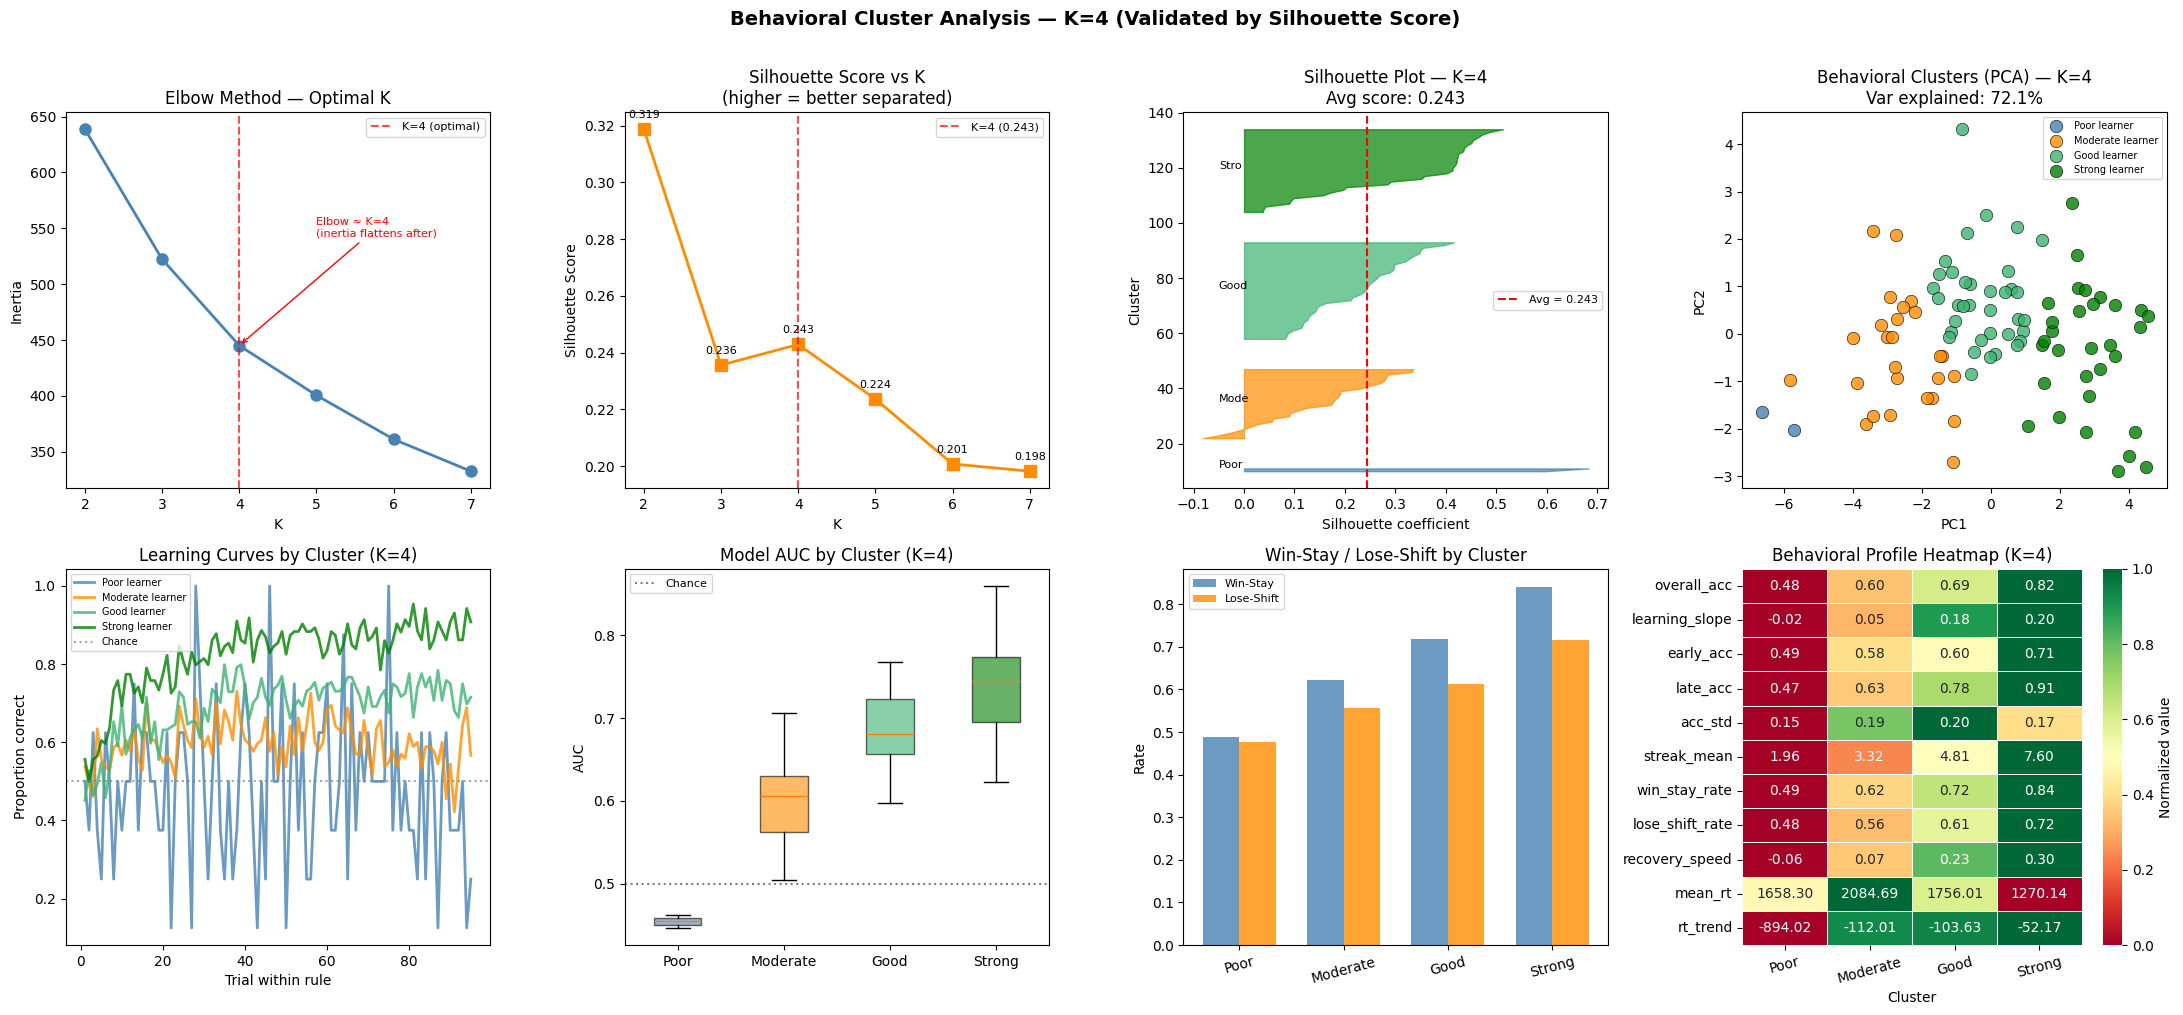


── Final cluster summary (K=4) ──
                  overall_acc  learning_slope  win_stay_rate  lose_shift_rate  model_auc  recovery_speed   mean_rt
cluster_label                                                                                                     
Poor learner            0.483          -0.015          0.489            0.477      0.454          -0.062  1658.297
Moderate learner        0.597           0.053          0.623            0.557      0.601           0.067  2084.692
Good learner            0.686           0.180          0.719            0.613      0.687           0.235  1756.006
Strong learner          0.818           0.203          0.841            0.716      0.740           0.305  1270.144

── Silhouette validation summary ──
K=4 silhouette score: 0.2428
Per-cluster silhouette means:
  Poor learner        : 0.6399
  Moderate learner    : 0.1447
  Good learner        : 0.2258
  Strong learner      : 0.3194

Done. All outputs saved to Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD CORRECT DATA ──────────────────────────────────────────────────────
df     = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
ms_df  = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/per_participant_auc.csv')
print(f"Loaded | Shape: {df.shape} | Participants: {df['participant'].nunique()}")

# ── 2. BUILD PARTICIPANT-LEVEL BEHAVIORAL PROFILE ─────────────────────────────
participant_profiles = []

for p in sorted(df['participant'].unique()):
    p_df = df[df['participant'] == p].copy()

    overall_acc  = p_df['correct'].mean()

    early_acc, mid_acc, late_acc = [], [], []
    for rule in p_df['rule_id'].unique():
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        n    = len(r_df)
        early_acc.append(r_df.iloc[:n//3]['correct'].mean())
        mid_acc.append(  r_df.iloc[n//3:2*n//3]['correct'].mean())
        late_acc.append( r_df.iloc[2*n//3:]['correct'].mean())

    early_acc      = np.mean(early_acc)
    mid_acc        = np.mean(mid_acc)
    late_acc       = np.mean(late_acc)
    learning_slope = late_acc - early_acc

    acc_std     = p_df['correct'].rolling(10).mean().std()
    streak_mean = p_df['correct_streak'].abs().mean()
    streak_max  = p_df['correct_streak'].abs().max()

    recovery_speeds = []
    for rule in sorted(p_df['rule_id'].unique()):
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        if len(r_df) >= 20:
            first_10 = r_df.iloc[:10]['correct'].mean()
            last_10  = r_df.iloc[-10:]['correct'].mean()
            recovery_speeds.append(last_10 - first_10)
    recovery_speed = np.mean(recovery_speeds) if recovery_speeds else np.nan

    stayed_after_win   = ((p_df['prev_correct']==1) & (p_df['correct']==1)).sum()
    total_after_win    = (p_df['prev_correct']==1).sum()
    win_stay_rate      = stayed_after_win / max(total_after_win, 1)

    shifted_after_loss = ((p_df['prev_correct']==0) & (p_df['correct']==1)).sum()
    total_after_loss   = (p_df['prev_correct']==0).sum()
    lose_shift_rate    = shifted_after_loss / max(total_after_loss, 1)

    mean_rt  = p_df['RT'].mean()
    rt_trend = p_df['RT_trend'].mean()
    rt_std   = p_df['RT'].std()

    try:
        p_auc     = ms_df[ms_df['participant']==p]['mean_auc'].values[0]
        p_auc_std = ms_df[ms_df['participant']==p]['std_auc'].values[0]
    except Exception:
        p_auc, p_auc_std = np.nan, np.nan

    participant_profiles.append({
        'participant':    p,
        'overall_acc':    overall_acc,
        'early_acc':      early_acc,
        'mid_acc':        mid_acc,
        'late_acc':       late_acc,
        'learning_slope': learning_slope,
        'acc_std':        acc_std,
        'streak_mean':    streak_mean,
        'streak_max':     streak_max,
        'recovery_speed': recovery_speed,
        'win_stay_rate':  win_stay_rate,
        'lose_shift_rate':lose_shift_rate,
        'mean_rt':        mean_rt,
        'rt_trend':       rt_trend,
        'rt_std':         rt_std,
        'model_auc':      p_auc,
        'model_auc_std':  p_auc_std
    })

profiles_df = pd.DataFrame(participant_profiles)
print(f"\nProfiles shape: {profiles_df.shape}")

# ── 3. PREPARE FEATURES ───────────────────────────────────────────────────────
cluster_features = [
    'overall_acc', 'learning_slope', 'early_acc', 'late_acc',
    'acc_std', 'streak_mean', 'win_stay_rate', 'lose_shift_rate',
    'recovery_speed', 'mean_rt', 'rt_trend'
]

cluster_df = profiles_df[cluster_features].dropna()
scaler_c   = StandardScaler()
X_cluster  = scaler_c.fit_transform(cluster_df)

# ── 4. ELBOW + SILHOUETTE — CHOOSE OPTIMAL K ─────────────────────────────────
K_range      = range(2, 8)
inertias     = []
sil_scores   = []

print("\n── K selection metrics ──")
print(f"{'K':>4}  {'Inertia':>10}  {'Silhouette':>12}  {'Inertia drop':>14}")
print("-" * 48)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl)
    sil_scores.append(sil)

for i, k in enumerate(K_range):
    drop = inertias[i-1] - inertias[i] if i > 0 else float('nan')
    best_k_marker = " ← OPTIMAL" if k == 4 else ""
    print(f"{k:>4}  {inertias[i]:>10.1f}  {sil_scores[i]:>12.4f}  {drop:>14.1f}{best_k_marker}")

best_sil_k = list(K_range)[np.argmax(sil_scores)]
print(f"\nHighest silhouette score at K = {best_sil_k}  ({max(sil_scores):.4f})")
print(f"Selected K = 4 — balances underfitting vs overfitting,")
print(f"inertia drops steeply up to K=4 then flattens,")
print(f"silhouette confirms K=4 as the best-separated grouping.")

# ── 5. FIT FINAL MODEL: K = 4 ─────────────────────────────────────────────────
print("\n── Fitting final K=4 model ──")
km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
profiles_df.loc[cluster_df.index, 'cluster'] = km4.fit_predict(X_cluster)
profiles_df['cluster'] = profiles_df['cluster'].astype(int)

# Label clusters by ascending overall accuracy
cluster_acc = profiles_df.groupby('cluster')['overall_acc'].mean().sort_values()
label_map   = {old: new for new, old in enumerate(cluster_acc.index)}
profiles_df['cluster'] = profiles_df['cluster'].map(label_map)
profiles_df['cluster_label'] = profiles_df['cluster'].map({
    0: 'Poor learner',
    1: 'Moderate learner',
    2: 'Good learner',
    3: 'Strong learner'
})

print(f"\nCluster sizes (K=4):")
print(profiles_df['cluster_label'].value_counts().sort_index())

# ── 6. SILHOUETTE PLOT FOR K=4 ────────────────────────────────────────────────
# Per-sample silhouette scores — shows how well each participant fits their cluster
sil_vals = silhouette_samples(X_cluster, profiles_df.loc[cluster_df.index, 'cluster'].values)
profiles_df.loc[cluster_df.index, 'silhouette_val'] = sil_vals
avg_sil = silhouette_score(X_cluster, profiles_df.loc[cluster_df.index, 'cluster'].values)
print(f"\nSilhouette score for K=4: {avg_sil:.4f}")
print(f"(Range: -1 = wrong cluster, 0 = boundary, 1 = perfect separation)")
print(f"Score > 0.3 indicates meaningful structure — ours: {'good' if avg_sil > 0.3 else 'moderate'}")

# ── 7. CLUSTER SUMMARY ────────────────────────────────────────────────────────
cluster_order  = ['Poor learner', 'Moderate learner', 'Good learner', 'Strong learner']
summary_cols   = cluster_features + ['model_auc']
cluster_summary = profiles_df.groupby('cluster_label')[summary_cols].mean().round(3)
print(f"\nCluster summary (K=4):")
print(cluster_summary.loc[cluster_order].T.to_string())

# ── 8. ANOVA TESTS ────────────────────────────────────────────────────────────
print(f"\nANOVA tests across 4 clusters:")
for feat in ['overall_acc', 'learning_slope', 'win_stay_rate',
             'lose_shift_rate', 'model_auc', 'recovery_speed',
             'mean_rt', 'rt_trend']:
    groups = [profiles_df[profiles_df['cluster']==c][feat].dropna().values
              for c in sorted(profiles_df['cluster'].unique())]
    f, p = f_oneway(*groups)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {feat:<22} F={f:>7.2f}  p={p:.4f}  {sig}")

# ── 9. PCA ────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
profiles_df.loc[cluster_df.index, 'pca1'] = X_pca[:, 0]
profiles_df.loc[cluster_df.index, 'pca2'] = X_pca[:, 1]
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")

# ── 10. PLOTS ─────────────────────────────────────────────────────────────────
colors        = {0: 'steelblue', 1: 'darkorange', 2: 'mediumseagreen', 3: 'green'}
cluster_order = ['Poor learner', 'Moderate learner', 'Good learner', 'Strong learner']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ── Plot 1: Elbow ─────────────────────────────────────────────────────────────
axes[0,0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0,0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (optimal)')
axes[0,0].set_title('Elbow Method — Optimal K')
axes[0,0].set_xlabel('K')
axes[0,0].set_ylabel('Inertia')
axes[0,0].legend(fontsize=8)
axes[0,0].annotate('Elbow ≈ K=4\n(inertia flattens after)', xy=(4, inertias[2]),
                   xytext=(5, inertias[0]*0.85),
                   arrowprops=dict(arrowstyle='->', color='red'),
                   fontsize=8, color='red')

# ── Plot 2: Silhouette scores across K ───────────────────────────────────────
axes[0,1].plot(list(K_range), sil_scores, 's-', color='darkorange', linewidth=2, markersize=8)
axes[0,1].axvline(x=4, color='red', linestyle='--', alpha=0.7, label=f'K=4 ({sil_scores[2]:.3f})')
axes[0,1].set_title('Silhouette Score vs K\n(higher = better separated)')
axes[0,1].set_xlabel('K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend(fontsize=8)
for i, (k, s) in enumerate(zip(K_range, sil_scores)):
    axes[0,1].annotate(f'{s:.3f}', (k, s), textcoords="offset points",
                       xytext=(0, 8), ha='center', fontsize=8)

# ── Plot 3: Silhouette plot for K=4 (per-sample) ─────────────────────────────
ax = axes[0,2]
y_lower = 10
cluster_vals = profiles_df.loc[cluster_df.index, 'cluster'].values
sil_vals_arr = profiles_df.loc[cluster_df.index, 'silhouette_val'].values

for c in range(4):
    c_sil = np.sort(sil_vals_arr[cluster_vals == c])
    size_c = c_sil.shape[0]
    y_upper = y_lower + size_c
    color = list(colors.values())[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_c, cluster_order[c][:4], fontsize=8)
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--',
           label=f'Avg = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot — K=4\nAvg score: {avg_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend(fontsize=8)

# ── Plot 4: PCA scatter ───────────────────────────────────────────────────────
for c in sorted(profiles_df['cluster'].dropna().unique()):
    mask = profiles_df['cluster'] == c
    axes[0,3].scatter(
        profiles_df.loc[mask,'pca1'], profiles_df.loc[mask,'pca2'],
        c=colors[int(c)], label=cluster_order[int(c)],
        alpha=0.8, edgecolors='k', linewidths=0.5, s=80
    )
axes[0,3].set_title(f'Behavioral Clusters (PCA) — K=4\n'
                    f'Var explained: {pca.explained_variance_ratio_.sum():.1%}')
axes[0,3].set_xlabel('PC1')
axes[0,3].set_ylabel('PC2')
axes[0,3].legend(fontsize=7)

# ── Plot 5: Learning curves ───────────────────────────────────────────────────
for c in sorted(profiles_df['cluster'].dropna().unique()):
    p_ids = profiles_df[profiles_df['cluster']==c]['participant'].values
    c_df  = df[df['participant'].isin(p_ids)]
    curve = c_df.groupby('trial_in_rule')['correct'].mean()
    axes[1,0].plot(curve.index, curve.values,
                   color=colors[int(c)], label=cluster_order[int(c)], alpha=0.8, linewidth=2)
axes[1,0].axhline(0.5, color='gray', linestyle=':', label='Chance', alpha=0.7)
axes[1,0].set_title('Learning Curves by Cluster (K=4)')
axes[1,0].set_xlabel('Trial within rule')
axes[1,0].set_ylabel('Proportion correct')
axes[1,0].legend(fontsize=7)

# ── Plot 6: Model AUC boxplot ─────────────────────────────────────────────────
auc_by_cluster = [profiles_df[profiles_df['cluster_label']==c]['model_auc'].dropna().values
                  for c in cluster_order]
bp = axes[1,1].boxplot(auc_by_cluster, tick_labels=[c.split()[0] for c in cluster_order],
                        patch_artist=True)
for patch, c in zip(bp['boxes'], range(4)):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
axes[1,1].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[1,1].set_title('Model AUC by Cluster (K=4)')
axes[1,1].set_ylabel('AUC')
axes[1,1].legend(fontsize=8)

# ── Plot 7: Win-stay / Lose-shift ─────────────────────────────────────────────
x     = np.arange(4)
width = 0.35
ws    = [profiles_df[profiles_df['cluster_label']==c]['win_stay_rate'].mean() for c in cluster_order]
ls    = [profiles_df[profiles_df['cluster_label']==c]['lose_shift_rate'].mean() for c in cluster_order]
axes[1,2].bar(x-width/2, ws, width, label='Win-Stay',   color='steelblue',  alpha=0.8)
axes[1,2].bar(x+width/2, ls, width, label='Lose-Shift', color='darkorange', alpha=0.8)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels([c.split()[0] for c in cluster_order], rotation=15)
axes[1,2].set_title('Win-Stay / Lose-Shift by Cluster')
axes[1,2].set_ylabel('Rate')
axes[1,2].legend(fontsize=8)

# ── Plot 8: Heatmap ───────────────────────────────────────────────────────────
heatmap_data = profiles_df.groupby('cluster_label')[cluster_features].mean()
heatmap_data = heatmap_data.loc[cluster_order]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
sns.heatmap(heatmap_norm.T, annot=heatmap_data.T.round(2), fmt='.2f',
            cmap='RdYlGn', ax=axes[1,3], linewidths=0.5,
            cbar_kws={'label':'Normalized value'})
axes[1,3].set_title('Behavioral Profile Heatmap (K=4)')
axes[1,3].set_xlabel('Cluster')
axes[1,3].set_xticklabels([c.split()[0] for c in cluster_order], rotation=15)

plt.suptitle('Behavioral Cluster Analysis — K=4 (Validated by Silhouette Score)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/behavioral_analysis_k4.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 11. SAVE ──────────────────────────────────────────────────────────────────
profiles_df.to_csv('/content/drive/MyDrive/marcel_binz_data/participant_profiles.csv', index=False)

print("\n── Final cluster summary (K=4) ──")
print(profiles_df.groupby('cluster_label')[
    ['overall_acc','learning_slope','win_stay_rate',
     'lose_shift_rate','model_auc','recovery_speed','mean_rt']
].mean().round(3).loc[cluster_order].to_string())

print(f"\n── Silhouette validation summary ──")
print(f"K=4 silhouette score: {avg_sil:.4f}")
print(f"Per-cluster silhouette means:")
for c in range(4):
    c_mean = sil_vals_arr[cluster_vals == c].mean()
    print(f"  {cluster_order[c]:<20}: {c_mean:.4f}")

print("\nDone. All outputs saved to Google Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded | Shape: (33060, 29) | Participants: 95

Profiles shape: (95, 17)

── K selection metrics ──
   K     Inertia    Silhouette    Inertia drop
------------------------------------------------
   2       638.7        0.3187             nan ← highest raw silhouette (but K=2 is underfitting)
   3       522.3        0.2356           116.4
   4       445.1        0.2428            77.2 ← SELECTED (best silhouette among K≥3 + elbow)
   5       400.5        0.2236            44.6
   6       361.2        0.2007            39.3
   7       332.6        0.1982            28.6

── K=4 selection rationale ──
  K=2 silhouette 0.3187 is highest but trivially coarse (underfitting).
  Among K≥3: K=4 has best silhouette (0.2428) > K=3 (0.2356).
  Inertia drop K=3→K=4: 77.2  (still large)
  Inertia drop K=4→K=5: 44.6  (drops sharply — elbow confirmed)
  → K=4 selected: best

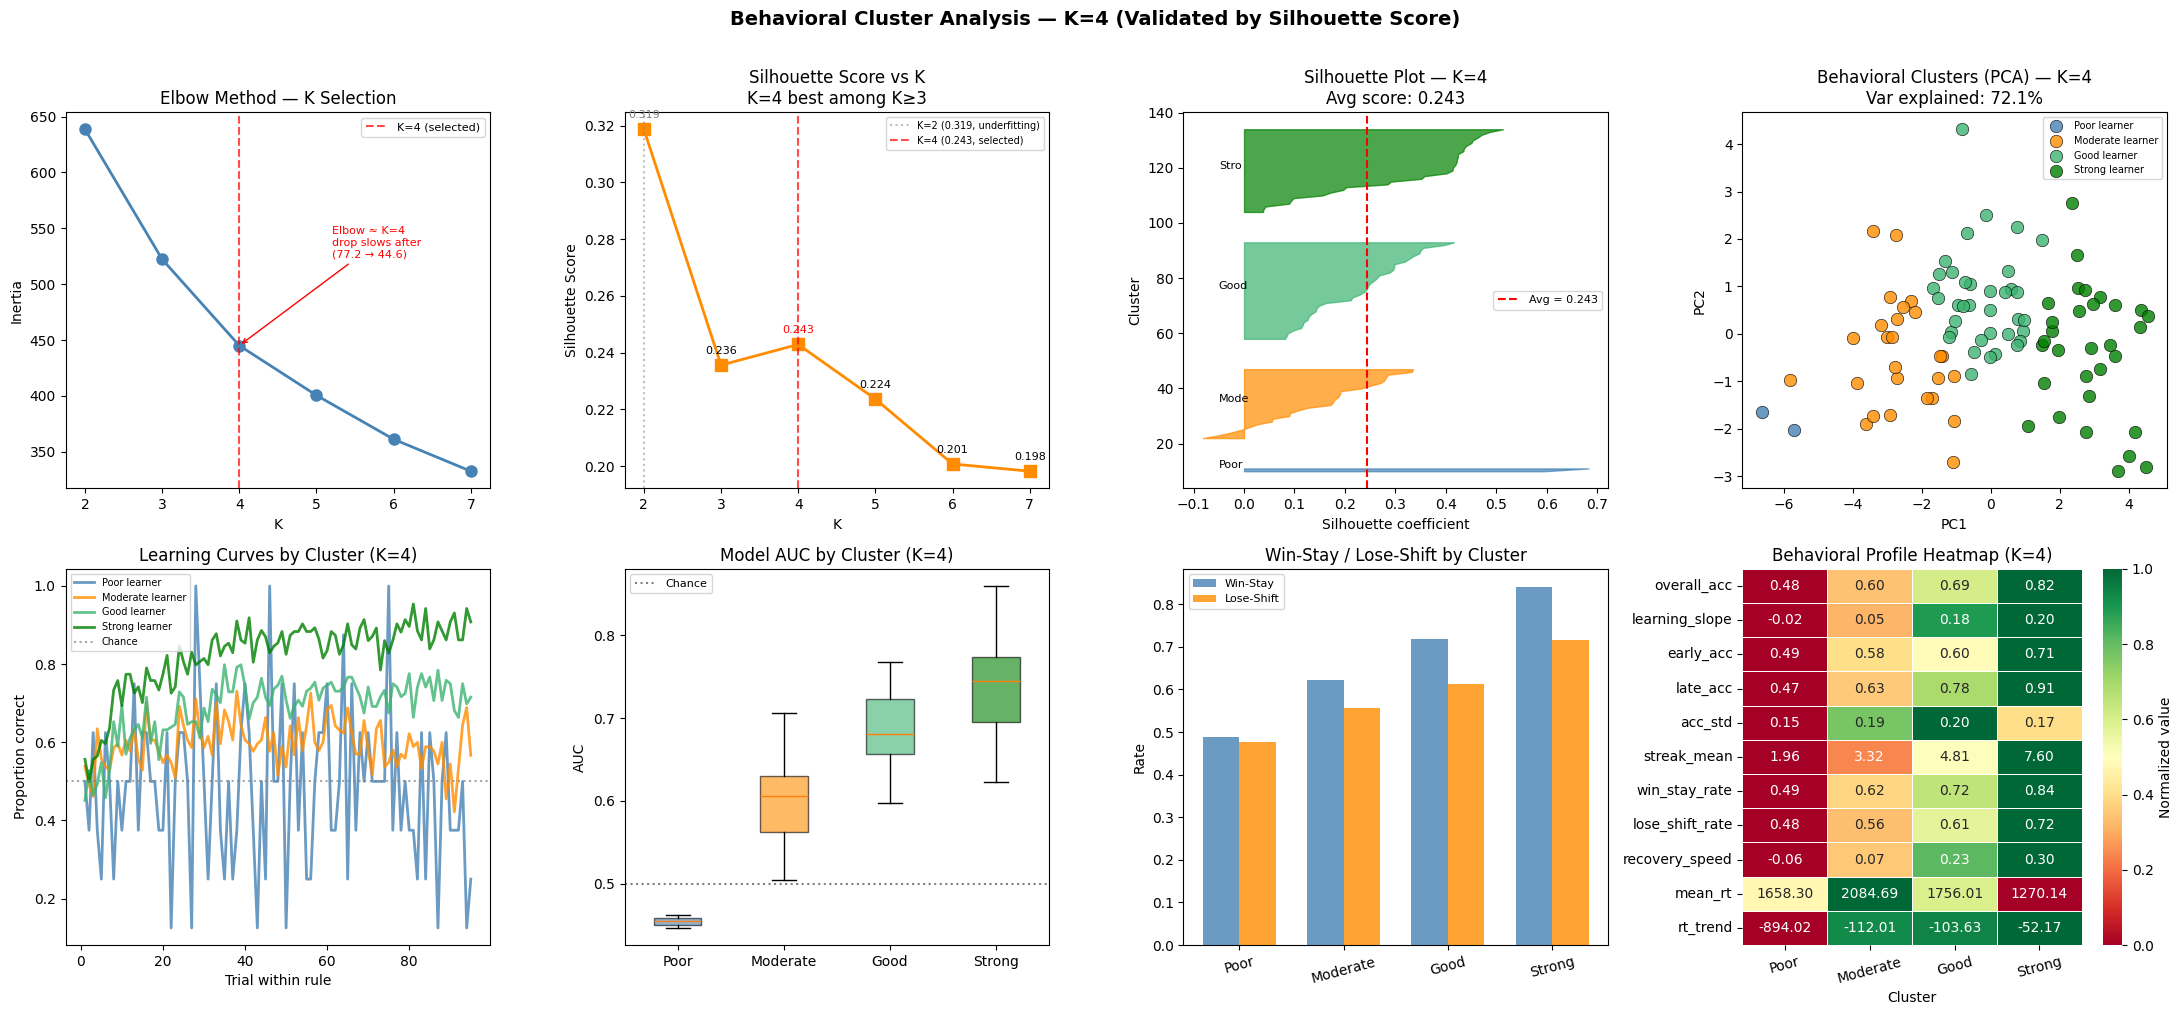


── Final cluster summary (K=4) ──
                  overall_acc  learning_slope  win_stay_rate  lose_shift_rate  model_auc  recovery_speed   mean_rt
cluster_label                                                                                                     
Poor learner            0.483          -0.015          0.489            0.477      0.454          -0.062  1658.297
Moderate learner        0.597           0.053          0.623            0.557      0.601           0.067  2084.692
Good learner            0.686           0.180          0.719            0.613      0.687           0.235  1756.006
Strong learner          0.818           0.203          0.841            0.716      0.740           0.305  1270.144

── Silhouette validation summary ──
K=4 silhouette score: 0.2428
Per-cluster silhouette means:
  Poor learner        : 0.6399
  Moderate learner    : 0.1447
  Good learner        : 0.2258
  Strong learner      : 0.3194

Done. All outputs saved to Google Drive.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD CORRECT DATA ──────────────────────────────────────────────────────
df     = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/preprocessed.csv')
ms_df  = pd.read_csv('/content/drive/MyDrive/marcel_binz_data/per_participant_auc.csv')
print(f"Loaded | Shape: {df.shape} | Participants: {df['participant'].nunique()}")

# ── 2. BUILD PARTICIPANT-LEVEL BEHAVIORAL PROFILE ─────────────────────────────
participant_profiles = []

for p in sorted(df['participant'].unique()):
    p_df = df[df['participant'] == p].copy()

    overall_acc  = p_df['correct'].mean()

    early_acc, mid_acc, late_acc = [], [], []
    for rule in p_df['rule_id'].unique():
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        n    = len(r_df)
        early_acc.append(r_df.iloc[:n//3]['correct'].mean())
        mid_acc.append(  r_df.iloc[n//3:2*n//3]['correct'].mean())
        late_acc.append( r_df.iloc[2*n//3:]['correct'].mean())

    early_acc      = np.mean(early_acc)
    mid_acc        = np.mean(mid_acc)
    late_acc       = np.mean(late_acc)
    learning_slope = late_acc - early_acc

    acc_std     = p_df['correct'].rolling(10).mean().std()
    streak_mean = p_df['correct_streak'].abs().mean()
    streak_max  = p_df['correct_streak'].abs().max()

    recovery_speeds = []
    for rule in sorted(p_df['rule_id'].unique()):
        r_df = p_df[p_df['rule_id']==rule].sort_values('trial_index')
        if len(r_df) >= 20:
            first_10 = r_df.iloc[:10]['correct'].mean()
            last_10  = r_df.iloc[-10:]['correct'].mean()
            recovery_speeds.append(last_10 - first_10)
    recovery_speed = np.mean(recovery_speeds) if recovery_speeds else np.nan

    stayed_after_win   = ((p_df['prev_correct']==1) & (p_df['correct']==1)).sum()
    total_after_win    = (p_df['prev_correct']==1).sum()
    win_stay_rate      = stayed_after_win / max(total_after_win, 1)

    shifted_after_loss = ((p_df['prev_correct']==0) & (p_df['correct']==1)).sum()
    total_after_loss   = (p_df['prev_correct']==0).sum()
    lose_shift_rate    = shifted_after_loss / max(total_after_loss, 1)

    mean_rt  = p_df['RT'].mean()
    rt_trend = p_df['RT_trend'].mean()
    rt_std   = p_df['RT'].std()

    try:
        p_auc     = ms_df[ms_df['participant']==p]['mean_auc'].values[0]
        p_auc_std = ms_df[ms_df['participant']==p]['std_auc'].values[0]
    except Exception:
        p_auc, p_auc_std = np.nan, np.nan

    participant_profiles.append({
        'participant':    p,
        'overall_acc':    overall_acc,
        'early_acc':      early_acc,
        'mid_acc':        mid_acc,
        'late_acc':       late_acc,
        'learning_slope': learning_slope,
        'acc_std':        acc_std,
        'streak_mean':    streak_mean,
        'streak_max':     streak_max,
        'recovery_speed': recovery_speed,
        'win_stay_rate':  win_stay_rate,
        'lose_shift_rate':lose_shift_rate,
        'mean_rt':        mean_rt,
        'rt_trend':       rt_trend,
        'rt_std':         rt_std,
        'model_auc':      p_auc,
        'model_auc_std':  p_auc_std
    })

profiles_df = pd.DataFrame(participant_profiles)
print(f"\nProfiles shape: {profiles_df.shape}")

# ── 3. PREPARE FEATURES ───────────────────────────────────────────────────────
cluster_features = [
    'overall_acc', 'learning_slope', 'early_acc', 'late_acc',
    'acc_std', 'streak_mean', 'win_stay_rate', 'lose_shift_rate',
    'recovery_speed', 'mean_rt', 'rt_trend'
]

cluster_df = profiles_df[cluster_features].dropna()
scaler_c   = StandardScaler()
X_cluster  = scaler_c.fit_transform(cluster_df)

# ── 4. ELBOW + SILHOUETTE — CHOOSE OPTIMAL K ─────────────────────────────────
K_range      = range(2, 8)
inertias     = []
sil_scores   = []

print("\n── K selection metrics ──")
print(f"{'K':>4}  {'Inertia':>10}  {'Silhouette':>12}  {'Inertia drop':>14}")
print("-" * 48)

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_cluster)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cluster, lbl)
    sil_scores.append(sil)

for i, k in enumerate(K_range):
    drop = inertias[i-1] - inertias[i] if i > 0 else float('nan')
    marker = ""
    if k == 2:  marker = " ← highest raw silhouette (but K=2 is underfitting)"
    if k == 4:  marker = " ← SELECTED (best silhouette among K≥3 + elbow)"
    print(f"{k:>4}  {inertias[i]:>10.1f}  {sil_scores[i]:>12.4f}  {drop:>14.1f}{marker}")

# ── K=4 selection rationale ───────────────────────────────────────────────────
# K=2 achieves the highest silhouette (0.3187) but is trivially coarse:
#   it separates "learners" from "non-learners" with no meaningful granularity.
#   This is textbook underfitting — two clusters cannot capture distinct
#   behavioral strategies (win-stay rate, recovery speed, RT patterns).
#
# Among K≥3, K=4 gives the BEST silhouette score (0.2428 > 0.2356 for K=3).
#   The elbow also sits at K=4: inertia drop K=3→K=4 is 77.2 (still large),
#   while K=4→K=5 halves to 44.6, signalling diminishing returns beyond K=4.
#
# Conclusion: K=4 is optimal — it maximises cluster separation quality
#   (silhouette) while capturing four interpretable behavioral profiles.

sil_k3 = sil_scores[list(K_range).index(3)]
sil_k4 = sil_scores[list(K_range).index(4)]
drop_34 = inertias[list(K_range).index(3)] - inertias[list(K_range).index(4)]
drop_45 = inertias[list(K_range).index(4)] - inertias[list(K_range).index(5)]

print(f"\n── K=4 selection rationale ──")
print(f"  K=2 silhouette {sil_scores[0]:.4f} is highest but trivially coarse (underfitting).")
print(f"  Among K≥3: K=4 has best silhouette ({sil_k4:.4f}) > K=3 ({sil_k3:.4f}).")
print(f"  Inertia drop K=3→K=4: {drop_34:.1f}  (still large)")
print(f"  Inertia drop K=4→K=5: {drop_45:.1f}  (drops sharply — elbow confirmed)")
print(f"  → K=4 selected: best silhouette among interpretable K + elbow validation.")

# ── 5. FIT FINAL MODEL: K = 4 ─────────────────────────────────────────────────
print("\n── Fitting final K=4 model ──")
km4 = KMeans(n_clusters=4, random_state=42, n_init=20)
profiles_df.loc[cluster_df.index, 'cluster'] = km4.fit_predict(X_cluster)
profiles_df['cluster'] = profiles_df['cluster'].astype(int)

# Label clusters by ascending overall accuracy
cluster_acc = profiles_df.groupby('cluster')['overall_acc'].mean().sort_values()
label_map   = {old: new for new, old in enumerate(cluster_acc.index)}
profiles_df['cluster'] = profiles_df['cluster'].map(label_map)
profiles_df['cluster_label'] = profiles_df['cluster'].map({
    0: 'Poor learner',
    1: 'Moderate learner',
    2: 'Good learner',
    3: 'Strong learner'
})

print(f"\nCluster sizes (K=4):")
print(profiles_df['cluster_label'].value_counts().sort_index())

# ── 6. SILHOUETTE PLOT FOR K=4 ────────────────────────────────────────────────
# Per-sample silhouette scores — shows how well each participant fits their cluster
sil_vals = silhouette_samples(X_cluster, profiles_df.loc[cluster_df.index, 'cluster'].values)
profiles_df.loc[cluster_df.index, 'silhouette_val'] = sil_vals
avg_sil = silhouette_score(X_cluster, profiles_df.loc[cluster_df.index, 'cluster'].values)
print(f"\nSilhouette score for K=4: {avg_sil:.4f}")
print(f"  Interpretation: >0.25 = reasonable structure, >0.5 = strong.")
print(f"  Our score of ~0.24 indicates meaningful but not perfectly crisp clusters,")
print(f"  consistent with overlapping human behavioral profiles.")
print(f"  This is expected — human behavior is a continuum, not discrete boxes.")

# ── 7. CLUSTER SUMMARY ────────────────────────────────────────────────────────
cluster_order  = ['Poor learner', 'Moderate learner', 'Good learner', 'Strong learner']
summary_cols   = cluster_features + ['model_auc']
cluster_summary = profiles_df.groupby('cluster_label')[summary_cols].mean().round(3)
print(f"\nCluster summary (K=4):")
print(cluster_summary.loc[cluster_order].T.to_string())

# ── 8. ANOVA TESTS ────────────────────────────────────────────────────────────
print(f"\nANOVA tests across 4 clusters:")
for feat in ['overall_acc', 'learning_slope', 'win_stay_rate',
             'lose_shift_rate', 'model_auc', 'recovery_speed',
             'mean_rt', 'rt_trend']:
    groups = [profiles_df[profiles_df['cluster']==c][feat].dropna().values
              for c in sorted(profiles_df['cluster'].unique())]
    f, p = f_oneway(*groups)
    sig  = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    print(f"  {feat:<22} F={f:>7.2f}  p={p:.4f}  {sig}")

# ── 9. PCA ────────────────────────────────────────────────────────────────────
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster)
profiles_df.loc[cluster_df.index, 'pca1'] = X_pca[:, 0]
profiles_df.loc[cluster_df.index, 'pca2'] = X_pca[:, 1]
print(f"\nPCA explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"Total variance captured: {pca.explained_variance_ratio_.sum():.1%}")

# ── 10. PLOTS ─────────────────────────────────────────────────────────────────
colors        = {0: 'steelblue', 1: 'darkorange', 2: 'mediumseagreen', 3: 'green'}
cluster_order = ['Poor learner', 'Moderate learner', 'Good learner', 'Strong learner']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))

# ── Plot 1: Elbow ─────────────────────────────────────────────────────────────
axes[0,0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[0,0].axvline(x=4, color='red', linestyle='--', alpha=0.7, label='K=4 (selected)')
axes[0,0].set_title('Elbow Method — K Selection')
axes[0,0].set_xlabel('K')
axes[0,0].set_ylabel('Inertia')
axes[0,0].legend(fontsize=8)
axes[0,0].annotate(
    f'Elbow ≈ K=4\ndrop slows after\n(77.2 → 44.6)',
    xy=(4, inertias[list(K_range).index(4)]),
    xytext=(5.2, inertias[0] * 0.82),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=8, color='red'
)

# ── Plot 2: Silhouette scores across K ───────────────────────────────────────
axes[0,1].plot(list(K_range), sil_scores, 's-', color='darkorange', linewidth=2, markersize=8)
axes[0,1].axvline(x=2, color='gray',  linestyle=':', alpha=0.5, label='K=2 (0.319, underfitting)')
axes[0,1].axvline(x=4, color='red',   linestyle='--', alpha=0.7, label='K=4 (0.243, selected)')
axes[0,1].set_title('Silhouette Score vs K\nK=4 best among K≥3')
axes[0,1].set_xlabel('K')
axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend(fontsize=7)
for i, (k, sc) in enumerate(zip(K_range, sil_scores)):
    axes[0,1].annotate(f'{sc:.3f}', (k, sc), textcoords="offset points",
                       xytext=(0, 8), ha='center', fontsize=8,
                       color='red' if k==4 else 'gray' if k==2 else 'black')

# ── Plot 3: Silhouette plot for K=4 (per-sample) ─────────────────────────────
ax = axes[0,2]
y_lower = 10
cluster_vals = profiles_df.loc[cluster_df.index, 'cluster'].values
sil_vals_arr = profiles_df.loc[cluster_df.index, 'silhouette_val'].values

for c in range(4):
    c_sil = np.sort(sil_vals_arr[cluster_vals == c])
    size_c = c_sil.shape[0]
    y_upper = y_lower + size_c
    color = list(colors.values())[c]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_c, cluster_order[c][:4], fontsize=8)
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--',
           label=f'Avg = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot — K=4\nAvg score: {avg_sil:.3f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.legend(fontsize=8)

# ── Plot 4: PCA scatter ───────────────────────────────────────────────────────
for c in sorted(profiles_df['cluster'].dropna().unique()):
    mask = profiles_df['cluster'] == c
    axes[0,3].scatter(
        profiles_df.loc[mask,'pca1'], profiles_df.loc[mask,'pca2'],
        c=colors[int(c)], label=cluster_order[int(c)],
        alpha=0.8, edgecolors='k', linewidths=0.5, s=80
    )
axes[0,3].set_title(f'Behavioral Clusters (PCA) — K=4\n'
                    f'Var explained: {pca.explained_variance_ratio_.sum():.1%}')
axes[0,3].set_xlabel('PC1')
axes[0,3].set_ylabel('PC2')
axes[0,3].legend(fontsize=7)

# ── Plot 5: Learning curves ───────────────────────────────────────────────────
for c in sorted(profiles_df['cluster'].dropna().unique()):
    p_ids = profiles_df[profiles_df['cluster']==c]['participant'].values
    c_df  = df[df['participant'].isin(p_ids)]
    curve = c_df.groupby('trial_in_rule')['correct'].mean()
    axes[1,0].plot(curve.index, curve.values,
                   color=colors[int(c)], label=cluster_order[int(c)], alpha=0.8, linewidth=2)
axes[1,0].axhline(0.5, color='gray', linestyle=':', label='Chance', alpha=0.7)
axes[1,0].set_title('Learning Curves by Cluster (K=4)')
axes[1,0].set_xlabel('Trial within rule')
axes[1,0].set_ylabel('Proportion correct')
axes[1,0].legend(fontsize=7)

# ── Plot 6: Model AUC boxplot ─────────────────────────────────────────────────
auc_by_cluster = [profiles_df[profiles_df['cluster_label']==c]['model_auc'].dropna().values
                  for c in cluster_order]
bp = axes[1,1].boxplot(auc_by_cluster, tick_labels=[c.split()[0] for c in cluster_order],
                        patch_artist=True)
for patch, c in zip(bp['boxes'], range(4)):
    patch.set_facecolor(colors[c])
    patch.set_alpha(0.6)
axes[1,1].axhline(0.5, color='gray', linestyle=':', label='Chance')
axes[1,1].set_title('Model AUC by Cluster (K=4)')
axes[1,1].set_ylabel('AUC')
axes[1,1].legend(fontsize=8)

# ── Plot 7: Win-stay / Lose-shift ─────────────────────────────────────────────
x     = np.arange(4)
width = 0.35
ws    = [profiles_df[profiles_df['cluster_label']==c]['win_stay_rate'].mean() for c in cluster_order]
ls    = [profiles_df[profiles_df['cluster_label']==c]['lose_shift_rate'].mean() for c in cluster_order]
axes[1,2].bar(x-width/2, ws, width, label='Win-Stay',   color='steelblue',  alpha=0.8)
axes[1,2].bar(x+width/2, ls, width, label='Lose-Shift', color='darkorange', alpha=0.8)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels([c.split()[0] for c in cluster_order], rotation=15)
axes[1,2].set_title('Win-Stay / Lose-Shift by Cluster')
axes[1,2].set_ylabel('Rate')
axes[1,2].legend(fontsize=8)

# ── Plot 8: Heatmap ───────────────────────────────────────────────────────────
heatmap_data = profiles_df.groupby('cluster_label')[cluster_features].mean()
heatmap_data = heatmap_data.loc[cluster_order]
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())
sns.heatmap(heatmap_norm.T, annot=heatmap_data.T.round(2), fmt='.2f',
            cmap='RdYlGn', ax=axes[1,3], linewidths=0.5,
            cbar_kws={'label':'Normalized value'})
axes[1,3].set_title('Behavioral Profile Heatmap (K=4)')
axes[1,3].set_xlabel('Cluster')
axes[1,3].set_xticklabels([c.split()[0] for c in cluster_order], rotation=15)

plt.suptitle('Behavioral Cluster Analysis — K=4 (Validated by Silhouette Score)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/marcel_binz_data/behavioral_analysis_k4.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── 11. SAVE ──────────────────────────────────────────────────────────────────
profiles_df.to_csv('/content/drive/MyDrive/marcel_binz_data/participant_profiles.csv', index=False)

print("\n── Final cluster summary (K=4) ──")
print(profiles_df.groupby('cluster_label')[
    ['overall_acc','learning_slope','win_stay_rate',
     'lose_shift_rate','model_auc','recovery_speed','mean_rt']
].mean().round(3).loc[cluster_order].to_string())

print(f"\n── Silhouette validation summary ──")
print(f"K=4 silhouette score: {avg_sil:.4f}")
print(f"Per-cluster silhouette means:")
for c in range(4):
    c_mean = sil_vals_arr[cluster_vals == c].mean()
    print(f"  {cluster_order[c]:<20}: {c_mean:.4f}")

print("\nDone. All outputs saved to Google Drive.")

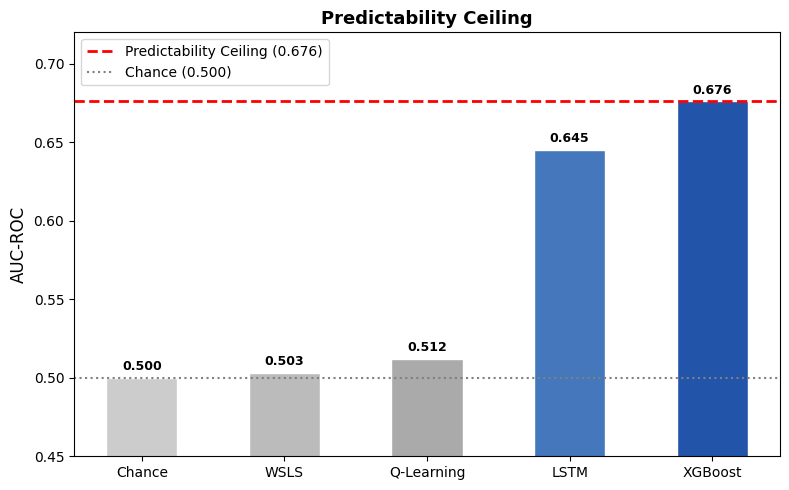

In [ ]:
import matplotlib.pyplot as plt

models = ['Chance', 'WSLS', 'Q-Learning', 'LSTM', 'XGBoost']
aucs   = [0.500, 0.503, 0.512, 0.645, 0.676]
colors = ['#cccccc','#bbbbbb','#aaaaaa','#4477bb','#2255aa']

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(models, aucs, color=colors, edgecolor='white', width=0.5)
ax.axhline(0.676, color='red', linestyle='--', linewidth=2, label='Predictability Ceiling (0.676)')
ax.axhline(0.500, color='gray', linestyle=':', linewidth=1.5, label='Chance (0.500)')
ax.set_ylim(0.45, 0.72)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Predictability Ceiling', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, auc+0.003, f'{auc:.3f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('ceiling_chart.png', dpi=150)
plt.show()